In [1]:
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
import os
import gc
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---- CREATE OUTPUT FOLDER ----
result_folder = r"D:\\Important\Semester\Semester X\MTP\Shimla Result"
os.makedirs(result_folder, exist_ok=True)

# ---- PATHS ----
full_data_path = r"D:\\Important\Semester\Semester X\MTP\LSI\shimla_dataset.parquet"
reference_raster = r"D:\\Important\Semester\Semester X\MTP\Raw data\landslide_distance.tif"
shapefile_path = r"D:\Important\Semester\Semester X\MTP\DATA\shimla shp\shimla_boundary_utm.shp"

# ---- LOAD DATA ----
print("Loading full dataset...")
df = pd.read_parquet(full_data_path)
df["lulc"] = df["lulc"].astype(np.int8)
print(f"Full dataset: {df.shape[0]:,} pixels ({df.shape[0] * 100 / 1_000_000:.2f} sq.km)")

# ---- FEATURE COLUMNS ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]
class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}

# ---- RASTER METADATA ----
with rasterio.open(reference_raster) as src:
    raster_transform = src.transform
    raster_crs = src.crs
    raster_width = src.width
    raster_height = src.height

Loading full dataset...
Full dataset: 51,423,700 pixels (5142.37 sq.km)


# Step 1


STEP P1: EXTRACT HIGH SUITABILITY ZONES

Full district class distribution:
  Class              Pixels   Area (sq.km) Percentage
  --------------------------------------------------
  1 Very Low      1,060,985        106.10      2.06%
  2 Low          13,055,064       1305.51     25.39%
  3 Moderate     31,455,011       3145.50     61.17%
  4 High          5,826,106        582.61     11.33%
  5 Very High        26,534          2.65      0.05%

High suitability pixels extracted:
  Class 4 (High):       5,826,106 pixels
  Class 5 (Very High):     26,534 pixels
  Total:                5,852,640 pixels
  Area:                585.26 sq.km
  % of district:       11.38%

Feature characteristics of high suitability zones:
  Feature                  Mean        Min        Max
  --------------------------------------------------
  landslide_dist        2806.06     145.60   17721.50
  slope                   23.42       0.00      88.91
  lulc                     6.52       1.00      11.00
  elev

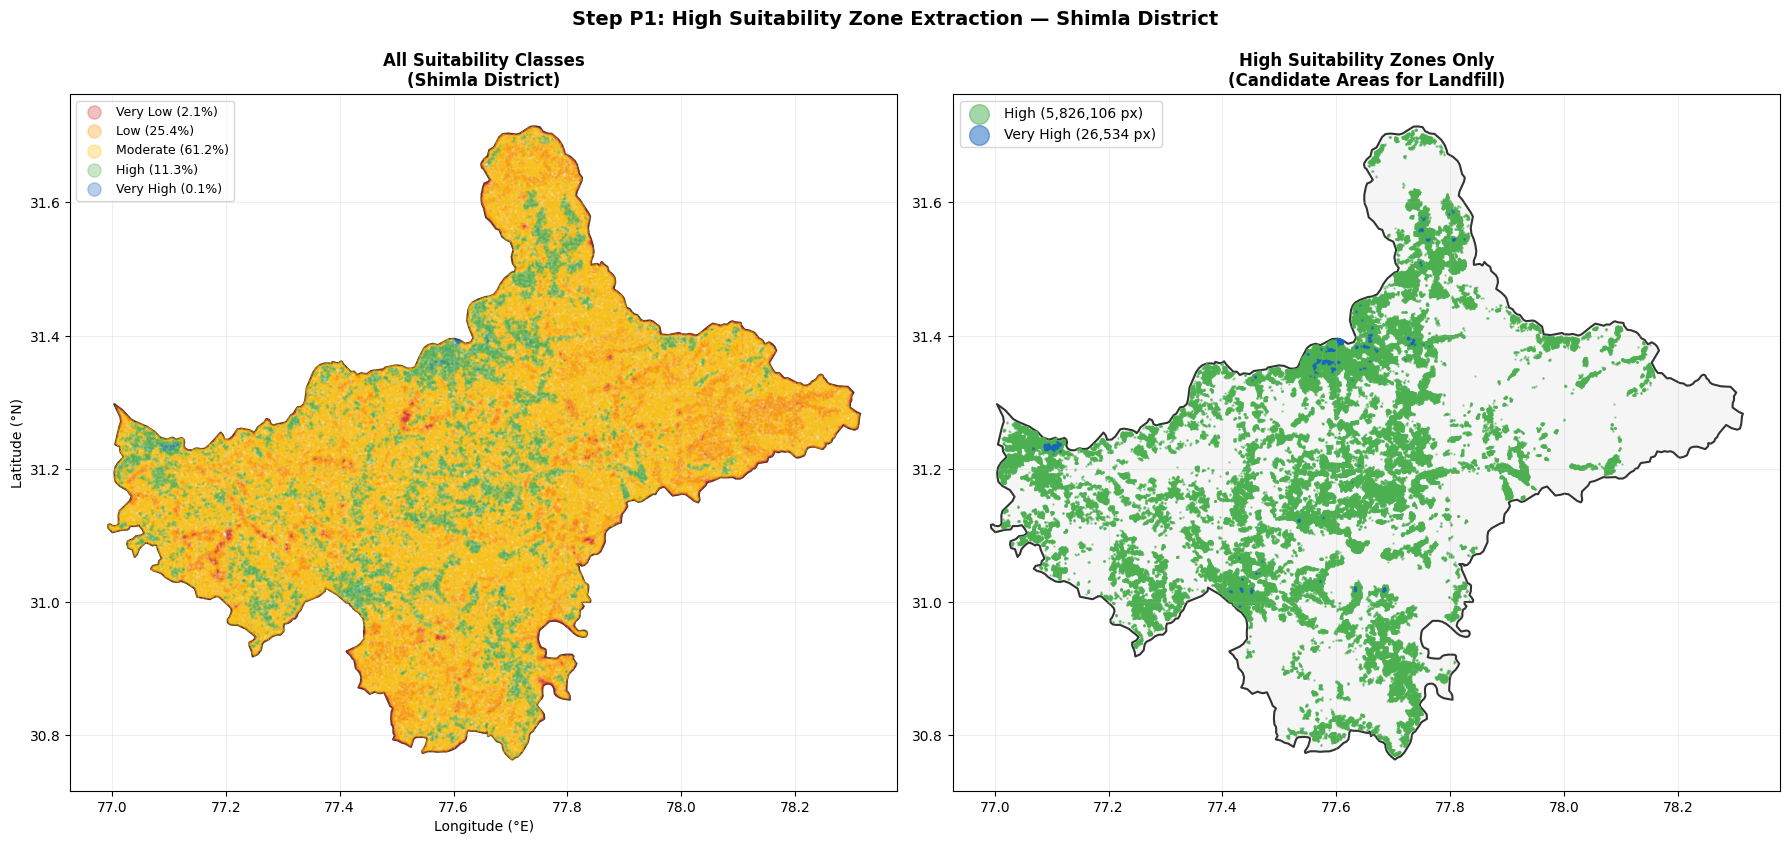


✓ Saved: P1_high_suitability_extraction.png


In [3]:
# ============================================================
# STEP P1: EXTRACT HIGH SUITABILITY ZONES
# ============================================================
print("\n" + "=" * 60)
print("STEP P1: EXTRACT HIGH SUITABILITY ZONES")
print("=" * 60)

# ---- FULL CLASS DISTRIBUTION ----
print("\nFull district class distribution:")
print(f"  {'Class':<12} {'Pixels':>12} {'Area (sq.km)':>14} {'Percentage':>10}")
print("  " + "-" * 50)
for cls in sorted(df["lsi_classified"].unique()):
    count = (df["lsi_classified"] == cls).sum()
    area = count * 100 / 1_000_000
    pct = (count / len(df)) * 100
    print(f"  {int(cls)} {class_labels[int(cls)]:<10} {count:>12,} {area:>13.2f} {pct:>9.2f}%")

# ---- EXTRACT CLASS 4 AND 5 ----
df_high = df[df["lsi_classified"].isin([4, 5])].copy().reset_index(drop=True)

print(f"\nHigh suitability pixels extracted:")
print(f"  Class 4 (High):      {(df_high['lsi_classified'] == 4).sum():>10,} pixels")
print(f"  Class 5 (Very High): {(df_high['lsi_classified'] == 5).sum():>10,} pixels")
print(f"  Total:               {len(df_high):>10,} pixels")
print(f"  Area:                {len(df_high) * 100 / 1_000_000:.2f} sq.km")
print(f"  % of district:       {len(df_high) / len(df) * 100:.2f}%")

# ---- FEATURE STATISTICS OF HIGH SUITABILITY PIXELS ----
print(f"\nFeature characteristics of high suitability zones:")
print(f"  {'Feature':<18} {'Mean':>10} {'Min':>10} {'Max':>10}")
print("  " + "-" * 50)
for col in feature_cols:
    print(f"  {col:<18} {df_high[col].mean():>10.2f} {df_high[col].min():>10.2f} {df_high[col].max():>10.2f}")

print(f"\n  LSI continuous: {df_high['lsi_continuous'].mean():.4f} mean, "
      f"{df_high['lsi_continuous'].min():.4f} min, {df_high['lsi_continuous'].max():.4f} max")

# ---- VISUALIZE HIGH SUITABILITY DISTRIBUTION ----
shimla = gpd.read_file(shapefile_path)
# Transformer
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

# Convert shapefile to lat/long
shimla_latlon = shimla.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: All suitability classes
ax1 = axes[0]
# Use lat/lon shapefile
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot all pixels as scatter (subsample for speed)
np.random.seed(42)
sample_all = df.sample(n=min(500_000, len(df)), random_state=42)

# Convert pixel coords to UTM for plotting
sample_x_utm = raster_transform.c + (sample_all["pixel_col"].values * raster_transform.a)
sample_y_utm = raster_transform.f + (sample_all["pixel_row"].values * raster_transform.e)
sample_x, sample_y = transformer_to_latlon.transform(sample_x_utm, sample_y_utm)

colors_map = {1: "#D32F2F", 2: "#FF9800", 3: "#FFC107", 4: "#4CAF50", 5: "#1565C0"}
for cls in [1, 2, 3, 4, 5]:
    mask = sample_all["lsi_classified"].values == cls
    if mask.sum() > 0:
        ax1.scatter(sample_x[mask], sample_y[mask], c=colors_map[cls], s=0.1, alpha=0.3,
                   label=f"{class_labels[cls]} ({(df['lsi_classified']==cls).sum()/len(df)*100:.1f}%)")

ax1.set_title("All Suitability Classes\n(Shimla District)", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9, markerscale=30)
ax1.set_xlabel("Easting (m)", fontsize=10)
ax1.set_ylabel("Northing (m)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: High suitability only
ax2 = axes[1]
# Use lat/lon shapefile
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot high suitability pixels
high_x_utm = raster_transform.c + (df_high["pixel_col"].values * raster_transform.a)
high_y_utm = raster_transform.f + (df_high["pixel_row"].values * raster_transform.e)
high_x, high_y = transformer_to_latlon.transform(high_x_utm, high_y_utm)

# Subsample if too many
if len(df_high) > 200_000:
    idx = np.random.choice(len(df_high), size=200_000, replace=False)
    high_x_plot = high_x[idx]
    high_y_plot = high_y[idx]
    high_cls_plot = df_high["lsi_classified"].values[idx]
else:
    high_x_plot = high_x
    high_y_plot = high_y
    high_cls_plot = df_high["lsi_classified"].values

for cls, color, label in [(4, "#4CAF50", "High"), (5, "#1565C0", "Very High")]:
    mask = high_cls_plot == cls
    if mask.sum() > 0:
        ax2.scatter(high_x_plot[mask], high_y_plot[mask], c=color, s=0.5, alpha=0.5,
                   label=f"{label} ({(df_high['lsi_classified']==cls).sum():,} px)")

ax2.set_title("High Suitability Zones Only\n(Candidate Areas for Landfill)", fontsize=12, fontweight="bold")
ax2.legend(loc="upper left", fontsize=10, markerscale=20)
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle("Step P1: High Suitability Zone Extraction — Shimla District",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P1_high_suitability_extraction.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P1_high_suitability_extraction.png")

# Step 2 & 3

STEP P2: CLUSTER CONNECTED PIXELS INTO CANDIDATE ZONES

Creating binary high-suitability raster...
  High suitability pixels placed: 5,852,640
Labeling connected components (8-connectivity)...
  Total clusters found: 33,374
Computing cluster sizes...

Cluster size distribution:
  Total clusters: 33,374
  Size Range                   Count  % of Clusters
  --------------------------------------------------
  1 pixel (0.01 ha)            5,831         17.47%
  2-10 pixels                 12,742         38.18%
  11-100 pixels (0.01-1 ha)   11,512         34.49%
  101-500 pixels (1-5 ha)      2,383          7.14%
  501-5000 pixels (5-50 ha)      755          2.26%
  5001-50000 (50-500 ha)         137          0.41%
  >50000 pixels (>500 ha)         14          0.04%

STEP P3: APPLY MINIMUM AREA THRESHOLD

Minimum area threshold: 10 hectares (1000 pixels)
  Clusters before filter: 33,374
  Clusters after filter:  549
  Clusters removed:       32,825

Surviving clusters (>= 10 ha):
  Cluster

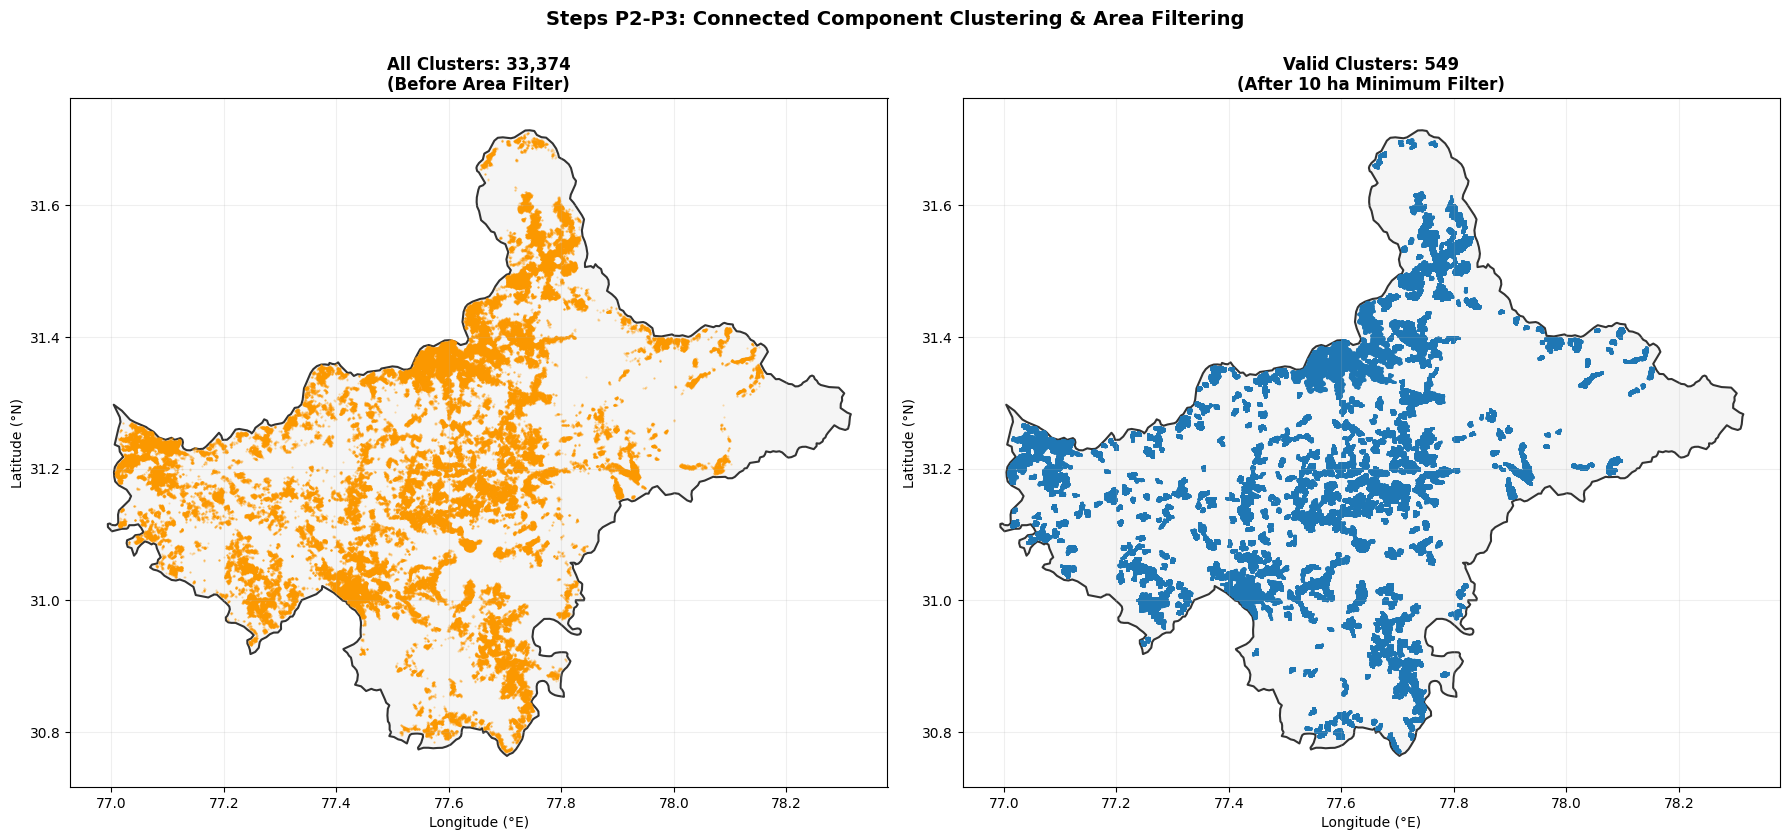


✓ Saved: P2_P3_clustering_and_filtering.png


12

In [4]:
from scipy import ndimage

# ============================================================
# STEP P2: CLUSTER CONNECTED HIGH SUITABILITY PIXELS
# ============================================================
print("=" * 60)
print("STEP P2: CLUSTER CONNECTED PIXELS INTO CANDIDATE ZONES")
print("=" * 60)

# ---- CREATE BINARY RASTER OF HIGH SUITABILITY ----
print("\nCreating binary high-suitability raster...")
high_raster = np.zeros((raster_height, raster_width), dtype=np.int8)
high_rows = df_high["pixel_row"].values
high_cols = df_high["pixel_col"].values
high_raster[high_rows, high_cols] = 1

print(f"  High suitability pixels placed: {high_raster.sum():,}")

# ---- LABEL CONNECTED COMPONENTS (8-connectivity) ----
print("Labeling connected components (8-connectivity)...")
structure = np.ones((3, 3), dtype=np.int8)  # 8-connectivity kernel
labeled_raster, num_clusters = ndimage.label(high_raster, structure=structure)

print(f"  Total clusters found: {num_clusters:,}")

# ---- COMPUTE CLUSTER SIZES ----
print("Computing cluster sizes...")
cluster_ids, cluster_sizes = np.unique(labeled_raster[labeled_raster > 0], return_counts=True)

# Convert to area
cluster_areas_sqm = cluster_sizes * 100  # each pixel = 100 sq.m
cluster_areas_ha = cluster_areas_sqm / 10_000  # hectares

print(f"\nCluster size distribution:")
print(f"  Total clusters: {len(cluster_ids):,}")
print(f"  {'Size Range':<25} {'Count':>8} {'% of Clusters':>14}")
print("  " + "-" * 50)

size_bins = [
    ("1 pixel (0.01 ha)", 1, 1),
    ("2-10 pixels", 2, 10),
    ("11-100 pixels (0.01-1 ha)", 11, 100),
    ("101-500 pixels (1-5 ha)", 101, 500),
    ("501-5000 pixels (5-50 ha)", 501, 5000),
    ("5001-50000 (50-500 ha)", 5001, 50000),
    (">50000 pixels (>500 ha)", 50001, float('inf'))
]

for label, low, high in size_bins:
    count = ((cluster_sizes >= low) & (cluster_sizes <= high)).sum()
    pct = (count / len(cluster_sizes)) * 100
    print(f"  {label:<25} {count:>8,} {pct:>13.2f}%")

# ============================================================
# STEP P3: APPLY MINIMUM AREA THRESHOLD
# ============================================================
print(f"\n{'=' * 60}")
print("STEP P3: APPLY MINIMUM AREA THRESHOLD")
print("=" * 60)

min_area_ha = 10  # minimum 5 hectares
min_pixels = int(min_area_ha * 10_000 / 100)  # 500 pixels

print(f"\nMinimum area threshold: {min_area_ha} hectares ({min_pixels} pixels)")

# Filter clusters by size
valid_mask = cluster_sizes >= min_pixels
valid_cluster_ids = cluster_ids[valid_mask]
valid_cluster_sizes = cluster_sizes[valid_mask]
valid_areas_ha = cluster_areas_ha[valid_mask]

print(f"  Clusters before filter: {len(cluster_ids):,}")
print(f"  Clusters after filter:  {len(valid_cluster_ids):,}")
print(f"  Clusters removed:       {len(cluster_ids) - len(valid_cluster_ids):,}")

print(f"\nSurviving clusters (>= {min_area_ha} ha):")
print(f"  {'Cluster ID':<12} {'Pixels':>10} {'Area (ha)':>12} {'Area (sq.km)':>14}")
print("  " + "-" * 50)

# Sort by size descending
sort_idx = np.argsort(valid_cluster_sizes)[::-1]
valid_cluster_ids = valid_cluster_ids[sort_idx]
valid_cluster_sizes = valid_cluster_sizes[sort_idx]
valid_areas_ha = valid_areas_ha[sort_idx]

for cid, size, area in zip(valid_cluster_ids, valid_cluster_sizes, valid_areas_ha):
    print(f"  {cid:<12} {size:>10,} {area:>12.2f} {area/100:>14.4f}")

total_valid_area = valid_areas_ha.sum()
print(f"\n  Total valid area: {total_valid_area:.2f} ha ({total_valid_area/100:.2f} sq.km)")
print(f"  % of district: {total_valid_area * 10_000 / (5143 * 1_000_000) * 100:.2f}%")

# ---- ASSIGN CLUSTER IDS TO DATAFRAME ----
print("\nAssigning cluster IDs to high-suitability pixels...")
df_high["cluster_id"] = labeled_raster[high_rows, high_cols]
df_high["cluster_valid"] = df_high["cluster_id"].isin(valid_cluster_ids)

print(f"  Pixels in valid clusters: {df_high['cluster_valid'].sum():,}")
print(f"  Pixels in removed clusters: {(~df_high['cluster_valid']).sum():,}")

# ---- VISUALIZE ----
print("\nGenerating cluster visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: All clusters (before filtering)
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

high_x_utm = raster_transform.c + (high_cols * raster_transform.a)
high_y_utm = raster_transform.f + (high_rows * raster_transform.e)
high_lon, high_lat = transformer_to_latlon.transform(high_x_utm, high_y_utm)

# Subsample for plotting
np.random.seed(42)
if len(high_lon) > 200_000:
    idx = np.random.choice(len(high_lon), size=200_000, replace=False)
else:
    idx = np.arange(len(high_lon))

ax1.scatter(high_lon[idx], high_lat[idx], c="#FF9800", s=0.3, alpha=0.3)
ax1.set_title(f"All Clusters: {num_clusters:,}\n(Before Area Filter)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: Valid clusters only (after filtering)
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot each valid cluster with different color
colors = plt.cm.tab20(np.linspace(0, 1, max(len(valid_cluster_ids), 1)))
for i, cid in enumerate(valid_cluster_ids):
    cluster_mask = df_high["cluster_id"].values == cid
    c_rows = high_rows[cluster_mask]
    c_cols = high_cols[cluster_mask]
    c_x_utm = raster_transform.c + (c_cols * raster_transform.a)
    c_y_utm = raster_transform.f + (c_rows * raster_transform.e)
    c_lon, c_lat = transformer_to_latlon.transform(c_x_utm, c_y_utm)
    
    # Subsample large clusters
    if len(c_lon) > 50_000:
        sub_idx = np.random.choice(len(c_lon), size=50_000, replace=False)
        c_lon, c_lat = c_lon[sub_idx], c_lat[sub_idx]
    
    ax2.scatter(c_lon, c_lat, c=[colors[i % 20]], s=0.5, alpha=0.5,
               label=f"C{cid} ({valid_areas_ha[i]:.1f} ha)")

ax2.set_title(f"Valid Clusters: {len(valid_cluster_ids)}\n(After {min_area_ha} ha Minimum Filter)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=10)
ax2.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

# Only show legend if reasonable number of clusters
if len(valid_cluster_ids) <= 20:
    ax2.legend(loc="upper left", fontsize=8, markerscale=20)

plt.suptitle("Steps P2-P3: Connected Component Clustering & Area Filtering",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P2_P3_clustering_and_filtering.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P2_P3_clustering_and_filtering.png")

# ---- FREE MEMORY ----
del high_raster, labeled_raster
gc.collect()

# Step 4

STEP P4: ENVIRONMENTAL CONSTRAINT FILTERING

Constraints applied:
  Distance from water > 200m [CPHEEO 2016]
  Distance from built-up > 500m [CPHEEO 2016]
  Distance from roads < 2000m [Accessibility requirement]
  Slope < 25 degrees [Construction feasibility]
  Distance from landslides > 500m [Safety requirement]
  Distance from lineaments > 150m [Groundwater protection]
  Elevation < 2400m [Paper Table 3 — Very Low suitability above 2400m]

Pixels before constraint filtering: 4,658,952
  Distance from water > 200m: 24,940 pixels removed (0.54%)
  Distance from built-up > 500m: 3,024,550 pixels removed (64.92%)
  Distance from roads < 2000m: 54,402 pixels removed (1.17%)
  Slope < 25 degrees: 1,928,528 pixels removed (41.39%)
  Distance from landslides > 500m: 14,720 pixels removed (0.32%)
  Distance from lineaments > 150m: 203,482 pixels removed (4.37%)
  Elevation < 2400m: 708,651 pixels removed (15.21%)

  Total pixels after ALL constraints: 361,690
  Total removed: 4,297,262 (92.2

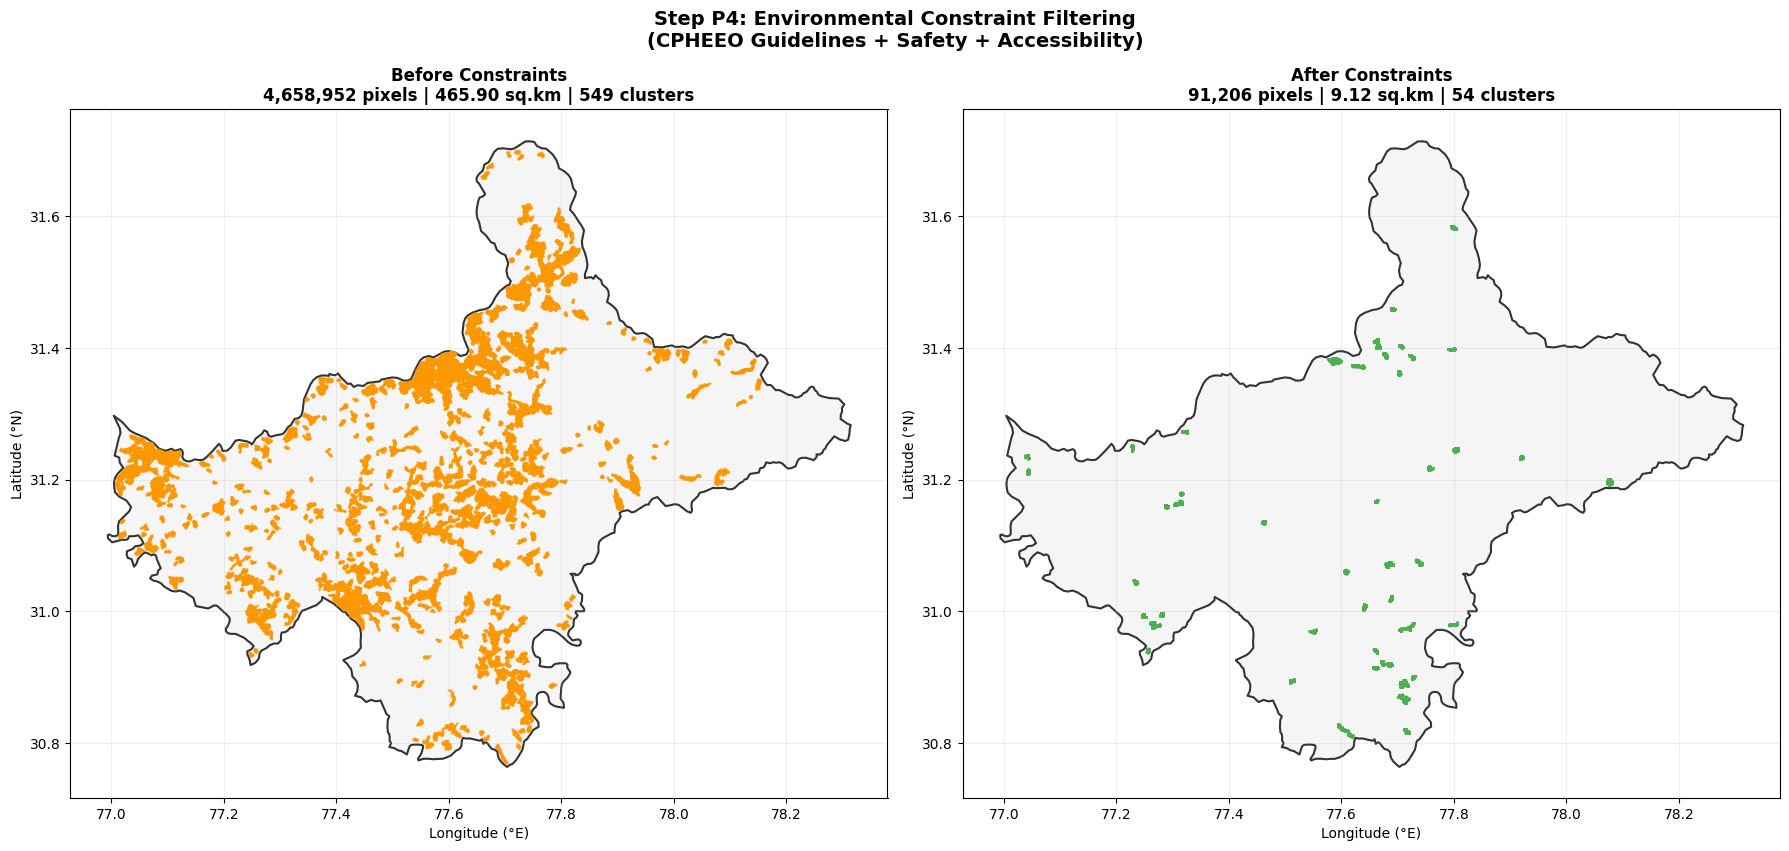


✓ Saved: P4_constraint_filtering.png


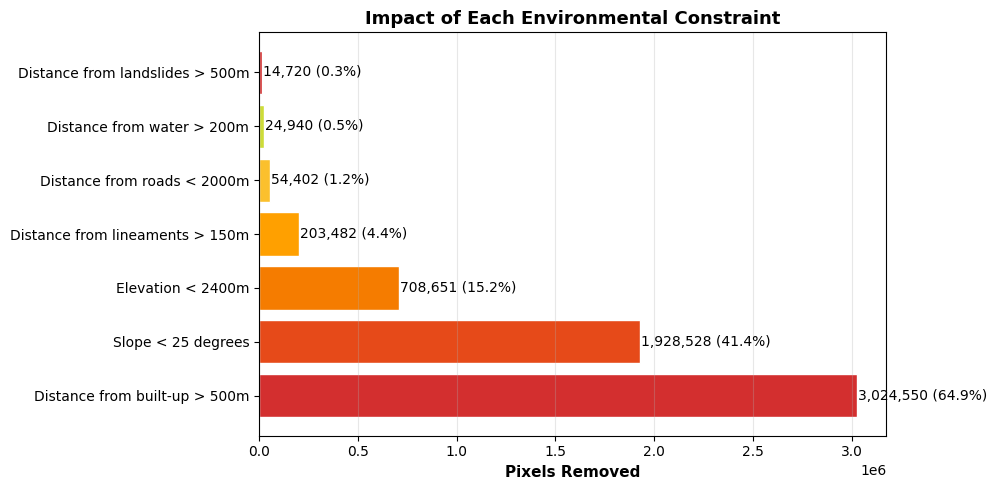

✓ Saved: P4_constraint_impact.png

REASONING AND METHODOLOGY NOTES

1. WHY THESE SPECIFIC CONSTRAINTS?
   - Water distance (>200m): CPHEEO 2016 mandates minimum 200m from ponds,
     lakes, and water bodies to prevent leachate contamination of surface
     water and aquatic ecosystems.
   - Built-up distance (>500m): CPHEEO 2016 requires all landfill facilities
     to maintain 500m from habitation to minimize health hazards (odor,
     disease vectors, noise) to nearby populations.
   - Road distance (<2000m): No landfill can operate without road access for
     waste transport vehicles. 2000m is the practical maximum distance in
     hilly terrain where building new access roads is extremely expensive.
     This threshold balances accessibility against the cost of road construction.
   - Slope (<25 degrees): Slopes above 25 degrees pose severe construction
     challenges in hilly terrain — heavy machinery cannot operate safely,
     waste containment is compromised, and landslide ri

In [5]:
# ============================================================
# STEP P4: APPLY ENVIRONMENTAL CONSTRAINT FILTERS
# ============================================================
print("=" * 60)
print("STEP P4: ENVIRONMENTAL CONSTRAINT FILTERING")
print("=" * 60)

# ---- DEFINE CONSTRAINTS (based on CPHEEO guidelines + practical criteria) ----
constraints = {
    "water_dist":     {"min": 200,  "label": "Distance from water > 200m",     "source": "CPHEEO 2016"},
    "builtup_dist":   {"min": 500,  "label": "Distance from built-up > 500m",  "source": "CPHEEO 2016"},
    "road_dist":      {"max": 2000, "label": "Distance from roads < 2000m",    "source": "Accessibility requirement"},
    "slope":          {"max": 25,   "label": "Slope < 25 degrees",             "source": "Construction feasibility"},
    "landslide_dist": {"min": 500,  "label": "Distance from landslides > 500m","source": "Safety requirement"},
    "lineament_dist": {"min": 150,  "label": "Distance from lineaments > 150m","source": "Groundwater protection"},
    "elevation":      {"max": 2400, "label": "Elevation < 2400m",              "source": "Paper Table 3 — Very Low suitability above 2400m"},
}

print("\nConstraints applied:")
for feat, params in constraints.items():
    if "min" in params:
        print(f"  {params['label']} [{params['source']}]")
    else:
        print(f"  {params['label']} [{params['source']}]")

# ---- FILTER ONLY VALID CLUSTER PIXELS ----
df_valid = df_high[df_high["cluster_valid"]].copy()
print(f"\nPixels before constraint filtering: {len(df_valid):,}")

# ---- APPLY EACH CONSTRAINT ----
constraint_results = {}
surviving_mask = np.ones(len(df_valid), dtype=bool)

for feat, params in constraints.items():
    if "min" in params:
        mask = df_valid[feat].values >= params["min"]
    else:
        mask = df_valid[feat].values <= params["max"]
    
    removed = (~mask).sum()
    pct_removed = (removed / len(df_valid)) * 100
    constraint_results[params["label"]] = {
        "removed": removed,
        "pct": pct_removed
    }
    surviving_mask &= mask
    print(f"  {params['label']}: {removed:,} pixels removed ({pct_removed:.2f}%)")

pixels_after = surviving_mask.sum()
total_removed = len(df_valid) - pixels_after
print(f"\n  Total pixels after ALL constraints: {pixels_after:,}")
print(f"  Total removed: {total_removed:,} ({total_removed/len(df_valid)*100:.2f}%)")

# ---- APPLY CONSTRAINT MASK ----
df_constrained = df_valid[surviving_mask].copy().reset_index(drop=True)

print(f"\n  Area after constraints: {len(df_constrained) * 100 / 1_000_000:.2f} sq.km")
print(f"  Area before constraints: {len(df_valid) * 100 / 1_000_000:.2f} sq.km")
print(f"  Area reduction: {(1 - len(df_constrained)/len(df_valid))*100:.2f}%")

# ============================================================
# RE-CLUSTER AFTER CONSTRAINT FILTERING
# ============================================================
print(f"\n{'=' * 60}")
print("RE-CLUSTERING AFTER CONSTRAINT REMOVAL")
print("=" * 60)

# Rebuild binary raster with only constrained pixels
print("Rebuilding binary raster with constrained pixels...")
constrained_raster = np.zeros((raster_height, raster_width), dtype=np.int8)
c_rows = df_constrained["pixel_row"].values
c_cols = df_constrained["pixel_col"].values
constrained_raster[c_rows, c_cols] = 1

print(f"  Constrained pixels placed: {constrained_raster.sum():,}")

# Re-label connected components
print("Re-labeling connected components (8-connectivity)...")
structure = np.ones((3, 3), dtype=np.int8)  # 8-connectivity: connects all 8 neighbors
labeled_constrained, num_clusters_new = ndimage.label(constrained_raster, structure=structure)

print(f"  Clusters found after constraints: {num_clusters_new:,}")

# Compute new cluster sizes
new_cluster_ids, new_cluster_sizes = np.unique(
    labeled_constrained[labeled_constrained > 0], return_counts=True
)
new_areas_ha = new_cluster_sizes * 100 / 10_000

# ---- RE-APPLY MINIMUM AREA THRESHOLD ----
print(f"\nRe-applying minimum area threshold ({min_area_ha} hectares)...")
valid_mask_new = new_cluster_sizes >= min_pixels
final_cluster_ids = new_cluster_ids[valid_mask_new]
final_cluster_sizes = new_cluster_sizes[valid_mask_new]
final_areas_ha = new_areas_ha[valid_mask_new]

# Sort by size descending
sort_idx = np.argsort(final_cluster_sizes)[::-1]
final_cluster_ids = final_cluster_ids[sort_idx]
final_cluster_sizes = final_cluster_sizes[sort_idx]
final_areas_ha = final_areas_ha[sort_idx]

print(f"  Clusters before area filter: {num_clusters_new:,}")
print(f"  Clusters after area filter: {len(final_cluster_ids):,}")

# ---- ASSIGN NEW CLUSTER IDS TO DATAFRAME ----
df_constrained["cluster_id_new"] = labeled_constrained[c_rows, c_cols]
df_constrained["cluster_final"] = df_constrained["cluster_id_new"].isin(final_cluster_ids)

final_pixels = df_constrained["cluster_final"].sum()
print(f"\n  Final candidate pixels: {final_pixels:,}")
print(f"  Final candidate area: {final_pixels * 100 / 1_000_000:.2f} sq.km")

# ---- SHOW TOP CANDIDATE CLUSTERS ----
print(f"\n{'=' * 60}")
print(f"SURVIVING CANDIDATE ZONES (Top 20 by area)")
print("=" * 60)

# Compute mean features for each final cluster
print(f"\n  {'Rank':<6} {'Cluster':<10} {'Pixels':>10} {'Area(ha)':>10} {'Mean LSI':>10} {'Mean Slope':>10} {'Mean Elev':>10}")
print("  " + "-" * 68)

cluster_stats = []
for rank, (cid, size, area) in enumerate(zip(final_cluster_ids[:20], final_cluster_sizes[:20], final_areas_ha[:20]), 1):
    cluster_mask = df_constrained["cluster_id_new"] == cid
    cluster_data = df_constrained[cluster_mask]
    
    mean_lsi = cluster_data["lsi_continuous"].mean()
    mean_slope = cluster_data["slope"].mean()
    mean_elev = cluster_data["elevation"].mean()
    mean_road = cluster_data["road_dist"].mean()
    mean_builtup = cluster_data["builtup_dist"].mean()
    mean_landslide = cluster_data["landslide_dist"].mean()
    
    cluster_stats.append({
        "rank": rank,
        "cluster_id": cid,
        "pixels": size,
        "area_ha": area,
        "mean_lsi": mean_lsi,
        "mean_slope": mean_slope,
        "mean_elevation": mean_elev,
        "mean_road_dist": mean_road,
        "mean_builtup_dist": mean_builtup,
        "mean_landslide_dist": mean_landslide
    })
    
    print(f"  {rank:<6} {cid:<10} {size:>10,} {area:>10.2f} {mean_lsi:>10.4f} {mean_slope:>10.2f} {mean_elev:>10.2f}")

cluster_stats_df = pd.DataFrame(cluster_stats)

# ---- VISUALIZE BEFORE vs AFTER CONSTRAINTS ----
print(f"\nGenerating constraint filtering visualization...")

shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Before constraints (all valid clusters from P3)
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

valid_rows = df_valid["pixel_row"].values
valid_cols = df_valid["pixel_col"].values
v_x_utm = raster_transform.c + (valid_cols * raster_transform.a)
v_y_utm = raster_transform.f + (valid_rows * raster_transform.e)
v_lon, v_lat = transformer_to_latlon.transform(v_x_utm, v_y_utm)

np.random.seed(42)
if len(v_lon) > 200_000:
    idx = np.random.choice(len(v_lon), size=200_000, replace=False)
    ax1.scatter(v_lon[idx], v_lat[idx], c="#FF9800", s=0.3, alpha=0.3)
else:
    ax1.scatter(v_lon, v_lat, c="#FF9800", s=0.3, alpha=0.3)

ax1.set_title(f"Before Constraints\n{len(df_valid):,} pixels | {len(df_valid)*100/1_000_000:.2f} sq.km | 549 clusters",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: After constraints (final valid clusters only)
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

final_data = df_constrained[df_constrained["cluster_final"]]
f_rows = final_data["pixel_row"].values
f_cols = final_data["pixel_col"].values
f_x_utm = raster_transform.c + (f_cols * raster_transform.a)
f_y_utm = raster_transform.f + (f_rows * raster_transform.e)
f_lon, f_lat = transformer_to_latlon.transform(f_x_utm, f_y_utm)

if len(f_lon) > 200_000:
    idx = np.random.choice(len(f_lon), size=200_000, replace=False)
    ax2.scatter(f_lon[idx], f_lat[idx], c="#4CAF50", s=0.5, alpha=0.4)
else:
    ax2.scatter(f_lon, f_lat, c="#4CAF50", s=0.5, alpha=0.4)

ax2.set_title(f"After Constraints\n{final_pixels:,} pixels | {final_pixels*100/1_000_000:.2f} sq.km | {len(final_cluster_ids)} clusters",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=10)
ax2.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle("Step P4: Environmental Constraint Filtering\n(CPHEEO Guidelines + Safety + Accessibility)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P4_constraint_filtering.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P4_constraint_filtering.png")

# ---- CONSTRAINT IMPACT SUMMARY CHART ----
fig, ax = plt.subplots(figsize=(10, 5))

c_labels = list(constraint_results.keys())
c_removed = [constraint_results[l]["removed"] for l in c_labels]

# Sort by impact
sort_idx = np.argsort(c_removed)[::-1]
c_labels = [c_labels[i] for i in sort_idx]
c_removed = [c_removed[i] for i in sort_idx]

colors = ["#D32F2F", "#E64A19", "#F57C00", "#FFA000", "#FBC02D", "#CDDC39"]
bars = ax.barh(range(len(c_labels)), c_removed, color=colors[:len(c_labels)], edgecolor="white")

for bar, val in zip(bars, c_removed):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/len(df_valid)*100:.1f}%)", va="center", fontsize=10)

ax.set_yticks(range(len(c_labels)))
ax.set_yticklabels(c_labels, fontsize=10)
ax.set_xlabel("Pixels Removed", fontsize=11, fontweight="bold")
ax.set_title("Impact of Each Environmental Constraint", fontsize=13, fontweight="bold")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P4_constraint_impact.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: P4_constraint_impact.png")

# ---- FREE MEMORY ----
del constrained_raster, labeled_constrained
gc.collect()

# ============================================================
# REASONING: WHY STEP P4 WAS DONE THIS WAY
# ============================================================
print(f"\n{'=' * 60}")
print("REASONING AND METHODOLOGY NOTES")
print("=" * 60)
print("""
1. WHY THESE SPECIFIC CONSTRAINTS?
   - Water distance (>200m): CPHEEO 2016 mandates minimum 200m from ponds,
     lakes, and water bodies to prevent leachate contamination of surface
     water and aquatic ecosystems.
   - Built-up distance (>500m): CPHEEO 2016 requires all landfill facilities
     to maintain 500m from habitation to minimize health hazards (odor,
     disease vectors, noise) to nearby populations.
   - Road distance (<2000m): No landfill can operate without road access for
     waste transport vehicles. 2000m is the practical maximum distance in
     hilly terrain where building new access roads is extremely expensive.
     This threshold balances accessibility against the cost of road construction.
   - Slope (<25 degrees): Slopes above 25 degrees pose severe construction
     challenges in hilly terrain — heavy machinery cannot operate safely,
     waste containment is compromised, and landslide risk increases. This
     threshold is consistent with the research paper's reclassification
     where slopes <25 degrees received the highest suitability rating.
   - Landslide distance (>500m): In Shimla's hilly terrain, proximity to
     known landslide zones creates structural instability risks. 500m buffer
     ensures the landfill foundation is on geologically stable ground. This
     is particularly critical because the SHAP analysis identified landslide
     proximity as the most important feature for suitability in this region.
   - Lineament distance (>150m): Geological lineaments (fractures/faults)
     create pathways for leachate to contaminate groundwater. 150m minimum
     is based on CPHEEO guidelines for protecting subsurface water resources.

2. WHY RE-CLUSTER AFTER CONSTRAINT REMOVAL?
   Removing constraint-violating pixels can split a previously contiguous
   cluster into disconnected fragments. For example, a 50-hectare cluster
   may have a river running through it — removing the 200m water buffer
   pixels splits it into two separate 20-hectare zones. Re-clustering with
   the same 8-connectivity identifies these new fragments correctly, and
   re-applying the 10-hectare minimum area filter removes any fragments
   that became too small after constraint removal.

3. WHY 8-CONNECTIVITY (not 4-connectivity)?
   8-connectivity considers all 8 neighbors (horizontal, vertical, diagonal).
   Two suitable land parcels touching diagonally are physically adjacent —
   a landfill boundary can include diagonal connections. 4-connectivity
   would artificially fragment contiguous suitable areas by ignoring
   diagonal adjacency, producing a misleading count of available sites.
   This is the standard approach in GIS-based land suitability studies.

4. SIGNIFICANCE FOR RESEARCH:
   The constraint impact chart shows which environmental factor most
   restricts landfill development in Shimla district. This is a practical
   finding — it tells planners which constraint is the binding limitation
   on waste management infrastructure development in hilly terrain.
""")

# Step 5

In [6]:
# ##############################################################
# STEP P5 — VIKOR-BASED LANDFILL SITE RANKING (paper-exact)
# Methodology: Chaturvedi et al. (2025), Waste Management Bulletin
#              Tables 5–11, Equations 6–11
#
# Three cells, run in order:
#   CELL 1  → Aggregate the 11 paper criteria per cluster, save to CSV
#   CELL 2  → Apply VIKOR with paper's AHP weights, rank candidates
#   CELL 3  → Visualize top sites and produce detailed profiles
# ##############################################################
 
 
# ==============================================================
# CELL 1 — PER-CLUSTER STATISTICS FOR THE 11 PAPER CRITERIA
# --------------------------------------------------------------
# Inputs:  df_constrained, final_cluster_ids/sizes/areas_ha, raster_transform
# Output:  P5_candidate_sites_stats.csv  (one row per surviving cluster)
# ==============================================================
print("=" * 60)
print("STEP P5 — CELL 1: PER-CLUSTER STATISTICS")
print("=" * 60)
 
# ---- Pre-flight: every raw paper criterion must exist in df_constrained ----
required_in_df = {
    "lsi_continuous":  "LSI composite from your earlier MCDA step",
    "landslide_dist":  "LSP — Landslide Proximity (m)",
    "lulc":            "LULC — raw class code (mapped to 1-5 below)",
    "water_dist":      "WBP — Water Body Proximity (m)",
    "builtup_dist":    "BUP — Built-Up Proximity (m)",
    "lineament_dist":  "LNP — Lineament Proximity (m)",
    "railway_dist":    "RAIL — Rail Proximity (m)",
    "slope":           "GSL — Ground Slope (deg)",
    "elevation":       "GEL — Ground Elevation (m)",
    "road_dist":       "ROAD — Road Proximity (m)",
    "land_value":      "LNV — Land Value (Rs/sq.ft)",
    "lst":             "LST — Land Surface Temperature (C)",
}
missing = [c for c in required_in_df if c not in df_constrained.columns]
if missing:
    print("\nERROR: df_constrained is missing required columns:")
    for c in missing:
        print(f"  - {c}: {required_in_df[c]}")
    print("\nAdd them in your data-loading step (P1/P2) by sampling each")
    print("source raster at every (pixel_row, pixel_col) of df_constrained.")
    raise KeyError(f"Missing columns in df_constrained: {missing}")
print("Pre-flight: all 11 raw paper criteria present in df_constrained")
 
# ---- LULC class code → paper Table 3 suitability score (1-5) ----
# Paper mapping:
#   Water Bodies = Very Low  (1)
#   Built-Up     = Low       (2)
#   Vegetation   = Moderate  (3)
#   Crops        = High      (4)
#   Barelands    = Very High (5)
#
# Default keys assume ESRI Sentinel-2 LULC class codes (paper's data source).
# CONFIRM these codes match your LULC raster — edit if different.
LULC_TO_SUITABILITY = {
    1:  1,   # Water
    9:  1,   # Snow/Ice (Unsuitable - ecological & operational risk)
    7:  2,   # Built area
    2:  3,   # Trees
    11: 3,   # Rangeland (shrub/grass) — treat as vegetation
    5:  4,   # Crops
    8:  5,   # Bare ground
}
 
df_constrained = df_constrained.copy()
df_constrained["lulc_suitability"] = df_constrained["lulc"].map(LULC_TO_SUITABILITY)
 
# Catch unmapped codes loudly — partial mapping would corrupt cluster means
n_unmapped = df_constrained["lulc_suitability"].isna().sum()
if n_unmapped > 0:
    unmapped_codes = sorted(df_constrained.loc[
        df_constrained["lulc_suitability"].isna(), "lulc"
    ].unique().tolist())
    raise ValueError(
        f"{n_unmapped} pixels have LULC class codes not in LULC_TO_SUITABILITY: "
        f"{unmapped_codes}. Add them to the dict (paper Table 3 has 5 classes; "
        f"map any extras to the closest of the five) and re-run."
    )
print("LULC class codes mapped to paper Table 3 suitability scores (1-5)")
 
# ---- Aggregate per cluster ----
print(f"\nAggregating statistics for {len(final_cluster_ids)} clusters...")
 
from pyproj import Transformer
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)
 
records = []
for cid, size, area in zip(final_cluster_ids, final_cluster_sizes, final_areas_ha):
    cd = df_constrained[df_constrained["cluster_id_new"] == cid]
 
    # Centroid (UTM → lat/lon)
    cx = raster_transform.c + (cd["pixel_col"].mean() * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].mean() * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
 
    # Compactness: filled fraction of bounding box (1 = perfect rectangle fill)
    rrange = cd["pixel_row"].max() - cd["pixel_row"].min() + 1
    crange = cd["pixel_col"].max() - cd["pixel_col"].min() + 1
    bbox_pixels = rrange * crange
    compactness = size / bbox_pixels if bbox_pixels > 0 else 0
 
    records.append({
        "cluster_id":          int(cid),
        "pixels":              int(size),
        "area_ha":             float(area),
        "area_sqkm":           float(area) / 100.0,
        # 11 paper criteria (raw values for distances/slope/etc; LULC as 1-5)
        "mean_lsi":            cd["lsi_continuous"].mean(),
        "mean_landslide_dist": cd["landslide_dist"].mean(),
        "mean_lulc":           cd["lulc_suitability"].mean(),
        "mean_water_dist":     cd["water_dist"].mean(),
        "mean_builtup_dist":   cd["builtup_dist"].mean(),
        "mean_lineament_dist": cd["lineament_dist"].mean(),
        "mean_rail_dist":      cd["railway_dist"].mean(),
        "mean_slope":          cd["slope"].mean(),
        "mean_elevation":      cd["elevation"].mean(),
        "mean_road_dist":      cd["road_dist"].mean(),
        "mean_land_value":     cd["land_value"].mean(),
        "mean_lst":            cd["lst"].mean(),
        # operational metadata
        "compactness":         compactness,
        "centroid_lon":        clon,
        "centroid_lat":        clat,
        "centroid_x_utm":      cx,
        "centroid_y_utm":      cy,
    })
 
stats_df = pd.DataFrame(records)
stats_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
stats_df.to_csv(stats_path, index=False)
 
print(f"  Aggregated {len(stats_df)} clusters")
print(f"  Total candidate area: {stats_df['area_ha'].sum():.2f} ha")
print(f"  Mean LSI range:       {stats_df['mean_lsi'].min():.3f} to {stats_df['mean_lsi'].max():.3f}")
print(f"  Saved: {stats_path}")
 
# Sanity peek: discriminative power of each criterion across the candidate pool
print(f"\nCriterion variance across candidates (low = poor discriminator):")
for c in ["mean_landslide_dist","mean_lulc","mean_water_dist","mean_builtup_dist",
          "mean_lineament_dist","mean_rail_dist","mean_slope","mean_elevation",
          "mean_road_dist","mean_land_value","mean_lst"]:
    s = stats_df[c]
    cv = s.std() / s.mean() if s.mean() != 0 else 0
    print(f"  {c:<22} mean={s.mean():>9.2f}  std={s.std():>9.2f}  CV={cv:.3f}")

STEP P5 — CELL 1: PER-CLUSTER STATISTICS
Pre-flight: all 11 raw paper criteria present in df_constrained
LULC class codes mapped to paper Table 3 suitability scores (1-5)

Aggregating statistics for 54 clusters...
  Aggregated 54 clusters
  Total candidate area: 912.06 ha
  Mean LSI range:       4.044 to 4.436
  Saved: D:\\Important\Semester\Semester X\MTP\Shimla Result\P5_candidate_sites_stats.csv

Criterion variance across candidates (low = poor discriminator):
  mean_landslide_dist    mean=  2841.59  std=  1829.53  CV=0.644
  mean_lulc              mean=     3.00  std=     0.01  CV=0.004
  mean_water_dist        mean=  3378.43  std=  2625.78  CV=0.777
  mean_builtup_dist      mean=   765.48  std=   189.85  CV=0.248
  mean_lineament_dist    mean=   996.50  std=   512.97  CV=0.515
  mean_rail_dist         mean= 45286.35  std= 20280.30  CV=0.448
  mean_slope             mean=    17.45  std=     2.11  CV=0.121
  mean_elevation         mean=  1732.39  std=   433.32  CV=0.250
  mean_road_

In [7]:
# ==============================================================
# CELL 2 — VIKOR RANKING (paper Eqs. 6–11, AHP weights from Table 6)
# --------------------------------------------------------------
# Inputs:  P5_candidate_sites_stats.csv
# Output:  P5_VIKOR_ranked_sites.csv  (adds Si, Ri, Qi, vikor_rank)
# ==============================================================
print("\n" + "=" * 60)
print("STEP P5 — CELL 2: VIKOR RANKING")
print("=" * 60)
 
stats_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
sites = pd.read_csv(stats_path)
print(f"Loaded {len(sites)} candidate sites")
 
# ---- The 11 paper criteria, with type (Table 5) ----
# NOTE: LSI is NOT a VIKOR criterion. Paper uses LSI for zoning only;
#       VIKOR runs on the 11 raw criteria. We follow that exactly to
#       avoid double-counting (LSI is itself a weighted sum of these 11).
criteria_meta = {
    # 6 BENEFICIAL — higher = better
    "mean_landslide_dist": {"code": "LSP",  "type": "beneficial"},
    "mean_lulc":           {"code": "LULC", "type": "beneficial"},
    "mean_water_dist":     {"code": "WBP",  "type": "beneficial"},
    "mean_builtup_dist":   {"code": "BUP",  "type": "beneficial"},
    "mean_lineament_dist": {"code": "LNP",  "type": "beneficial"},
    "mean_rail_dist":      {"code": "RAIL", "type": "beneficial"},
    # 5 NON-BENEFICIAL — lower = better
    "mean_slope":          {"code": "GSL",  "type": "non-beneficial"},
    "mean_elevation":      {"code": "GEL",  "type": "non-beneficial"},
    "mean_road_dist":      {"code": "ROAD", "type": "non-beneficial"},
    "mean_land_value":     {"code": "LNV",  "type": "non-beneficial"},
    "mean_lst":            {"code": "LST",  "type": "non-beneficial"},
}
criteria_cols = list(criteria_meta.keys())
 
# ---- AHP weights from paper Table 6 (CR = 0.045, sum = 1.000) ----
ahp_weights = {
    "mean_landslide_dist": 0.162,  # LSP  rank 1
    "mean_slope":          0.138,  # GSL  rank 2
    "mean_lulc":           0.122,  # LULC rank 3
    "mean_elevation":      0.114,  # GEL  rank 4
    "mean_road_dist":      0.095,  # ROAD rank 5
    "mean_builtup_dist":   0.084,  # BUP  rank 6
    "mean_land_value":     0.079,  # LNV  rank 7
    "mean_water_dist":     0.061,  # WBP  rank 8
    "mean_lineament_dist": 0.056,  # LNP  rank 9
    "mean_lst":            0.048,  # LST  rank 10
    "mean_rail_dist":      0.041,  # RAIL rank 11
}
weights = np.array([ahp_weights[c] for c in criteria_cols])
assert abs(weights.sum() - 1.0) < 1e-6, f"AHP weights must sum to 1, got {weights.sum()}"
 
# ---- Decision matrix ----
X = sites[criteria_cols].values.astype(np.float64)
n_sites, n_criteria = X.shape
print(f"\nDecision matrix: {n_sites} sites x {n_criteria} criteria")
 
# ---- Normalization (paper Eqs. 6 & 7) ----
# Both forms produce values where 0 = ideal best, 1 = worst.
R = np.zeros_like(X)
for j, col in enumerate(criteria_cols):
    x = X[:, j]
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        R[:, j] = 0.0                              # constant column → all tied
    elif criteria_meta[col]["type"] == "beneficial":
        R[:, j] = (xmax - x) / (xmax - xmin)       # Eq. 6: distance from best (max)
    else:
        R[:, j] = (x - xmin) / (xmax - xmin)       # Eq. 7: distance from best (min)
 
# ---- Weighted normalized matrix V (Eq. 8) ----
V = R * weights
 
# ---- Si (utility, Eq. 9) and Ri (regret, Eq. 10) ----
S  = V.sum(axis=1)
Rg = V.max(axis=1)
 
# ---- Qi (compromise index, Eq. 11), v = 0.5 (paper standard) ----
v = 0.5
S_star, S_minus = S.min(),  S.max()
R_star, R_minus = Rg.min(), Rg.max()
Q_S = np.zeros(n_sites) if S_minus == S_star else v       * (S  - S_star) / (S_minus - S_star)
Q_R = np.zeros(n_sites) if R_minus == R_star else (1 - v) * (Rg - R_star) / (R_minus - R_star)
Q = Q_S + Q_R
 
# ---- Attach + rank (lowest Qi = best site) ----
sites["Si"]         = S
sites["Ri"]         = Rg
sites["Qi"]         = Q
sites["vikor_rank"] = sites["Qi"].rank(method="min").astype(int)
sites = sites.sort_values("vikor_rank").reset_index(drop=True)
 
ranked_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
sites.to_csv(ranked_path, index=False)
 
# ---- Report ----
print(f"\nAHP weights applied (paper Table 6):")
for c in criteria_cols:
    print(f"  {criteria_meta[c]['code']:>4}  {ahp_weights[c]:.3f}  ({criteria_meta[c]['type']})")
print(f"  SUM   {weights.sum():.3f}")
 
print(f"\nv = {v} (balanced utility-regret)")
print(f"  Si: [{S.min():.4f}, {S.max():.4f}]    S* = {S_star:.4f}  S- = {S_minus:.4f}")
print(f"  Ri: [{Rg.min():.4f}, {Rg.max():.4f}]    R* = {R_star:.4f}  R- = {R_minus:.4f}")
print(f"  Qi: [{Q.min():.4f}, {Q.max():.4f}]")
 
print(f"\nTOP 15 by VIKOR Qi (lowest = best):")
print(f"  {'Rk':<3} {'Qi':>6} {'Si':>6} {'Ri':>6} {'Area':>6} "
      f"{'LSP':>5} {'GSL':>5} {'GEL':>5} {'ROAD':>5} {'Lat':>8} {'Lon':>8}")
print("  " + "-" * 78)
for _, row in sites.head(15).iterrows():
    print(f"  {int(row['vikor_rank']):<3} {row['Qi']:>6.3f} {row['Si']:>6.3f} {row['Ri']:>6.3f} "
          f"{row['area_ha']:>6.1f} {row['mean_landslide_dist']:>5.0f} "
          f"{row['mean_slope']:>5.1f} {row['mean_elevation']:>5.0f} "
          f"{row['mean_road_dist']:>5.0f} "
          f"{row['centroid_lat']:>8.4f} {row['centroid_lon']:>8.4f}")
 
print(f"\nSaved: {ranked_path}")


STEP P5 — CELL 2: VIKOR RANKING
Loaded 54 candidate sites

Decision matrix: 54 sites x 11 criteria

AHP weights applied (paper Table 6):
   LSP  0.162  (beneficial)
  LULC  0.122  (beneficial)
   WBP  0.061  (beneficial)
   BUP  0.084  (beneficial)
   LNP  0.056  (beneficial)
  RAIL  0.041  (beneficial)
   GSL  0.138  (non-beneficial)
   GEL  0.114  (non-beneficial)
  ROAD  0.095  (non-beneficial)
   LNV  0.079  (non-beneficial)
   LST  0.048  (non-beneficial)
  SUM   1.000

v = 0.5 (balanced utility-regret)
  Si: [0.4431, 0.7824]    S* = 0.4431  S- = 0.7824
  Ri: [0.1220, 0.1620]    R* = 0.1220  R- = 0.1620
  Qi: [0.0000, 0.9090]

TOP 15 by VIKOR Qi (lowest = best):
  Rk      Qi     Si     Ri   Area   LSP   GSL   GEL  ROAD      Lat      Lon
  ------------------------------------------------------------------------------
  1    0.000  0.443  0.122   14.0  3683  14.7  1015    69  30.8915  77.7140
  2    0.064  0.486  0.122   16.9  6340  11.6  2354   188  30.8940  77.5112
  3    0.137  


STEP P5 — CELL 3: TOP SITES PROFILE & VISUALIZATION

Detailed profile — top 5 sites:

  --- VIKOR RANK #1  (Qi = 0.0000) ---
  Cluster ID:       4211
  Location:         30.8915N, 77.7140E
  Area:             14.02 ha (0.1402 sq.km)
  LSI (zoning):     4.4272
  Beneficial criteria (higher = better):
    LSP landslide:    3683 m
    LULC suit (1-5):  3.00
    WBP water:        467 m
    BUP built-up:     1268 m
    LNP lineament:    2242 m
    RAIL:             56985 m
  Non-beneficial criteria (lower = better):
    GSL slope:        14.66 deg
    GEL elevation:    1015 m
    ROAD:             69 m
    LNV land value:   Rs. 667/sq.ft
    LST:              26.88 C
  VIKOR components: Si = 0.4431   Ri = 0.1220
  Operational:      compactness = 0.164

  --- VIKOR RANK #2  (Qi = 0.0639) ---
  Cluster ID:       4228
  Location:         30.8940N, 77.5112E
  Area:             16.86 ha (0.1686 sq.km)
  LSI (zoning):     4.0480
  Beneficial criteria (higher = better):
    LSP landslide:    6340

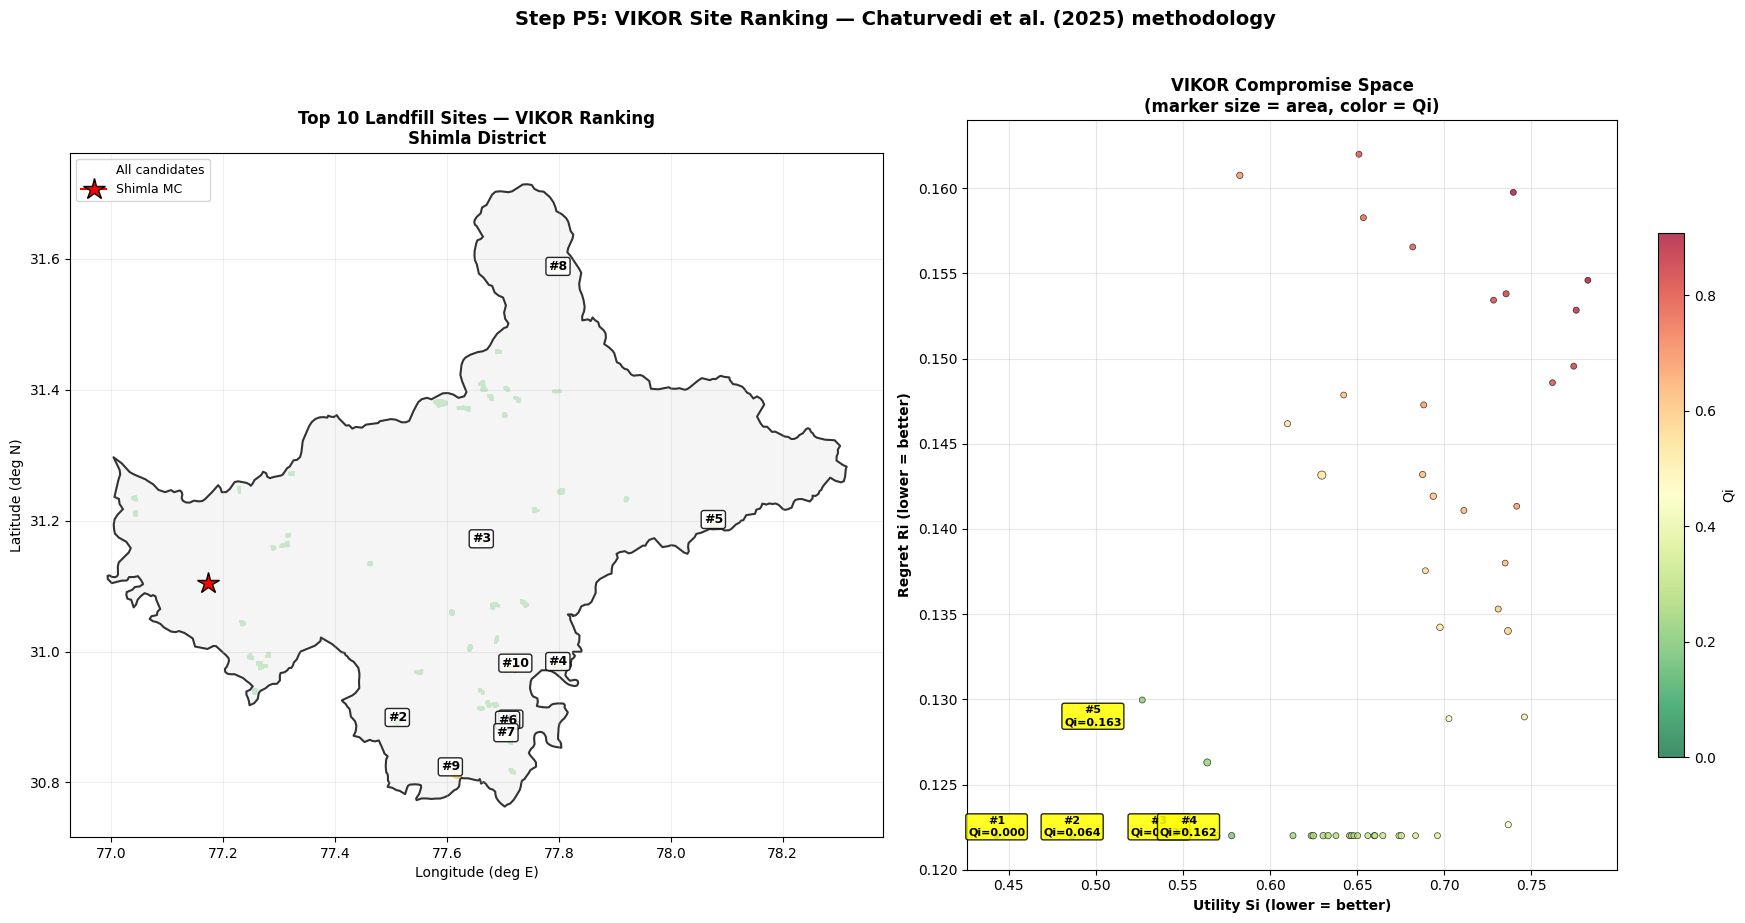

Saved: D:\\Important\Semester\Semester X\MTP\Shimla Result\P5_VIKOR_ranking.png


In [8]:
# ==============================================================
# CELL 3 — DETAILED PROFILE + VISUALIZATION OF TOP-RANKED SITES
# --------------------------------------------------------------
# Inputs:  P5_VIKOR_ranked_sites.csv, df_constrained, shimla, raster_transform
# Output:  P5_VIKOR_ranking.png + console profile of top 5
# ==============================================================
print("\n" + "=" * 60)
print("STEP P5 — CELL 3: TOP SITES PROFILE & VISUALIZATION")
print("=" * 60)
 
ranked_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
sites = pd.read_csv(ranked_path)
 
TOP_N_PROFILE = 5
TOP_N_MAP     = 10
 
# ---- DETAILED PROFILE ----
print(f"\nDetailed profile — top {TOP_N_PROFILE} sites:")
for _, row in sites.head(TOP_N_PROFILE).iterrows():
    print(f"\n  --- VIKOR RANK #{int(row['vikor_rank'])}  (Qi = {row['Qi']:.4f}) ---")
    print(f"  Cluster ID:       {int(row['cluster_id'])}")
    print(f"  Location:         {row['centroid_lat']:.4f}N, {row['centroid_lon']:.4f}E")
    print(f"  Area:             {row['area_ha']:.2f} ha ({row['area_sqkm']:.4f} sq.km)")
    print(f"  LSI (zoning):     {row['mean_lsi']:.4f}")
    print(f"  Beneficial criteria (higher = better):")
    print(f"    LSP landslide:    {row['mean_landslide_dist']:.0f} m")
    print(f"    LULC suit (1-5):  {row['mean_lulc']:.2f}")
    print(f"    WBP water:        {row['mean_water_dist']:.0f} m")
    print(f"    BUP built-up:     {row['mean_builtup_dist']:.0f} m")
    print(f"    LNP lineament:    {row['mean_lineament_dist']:.0f} m")
    print(f"    RAIL:             {row['mean_rail_dist']:.0f} m")
    print(f"  Non-beneficial criteria (lower = better):")
    print(f"    GSL slope:        {row['mean_slope']:.2f} deg")
    print(f"    GEL elevation:    {row['mean_elevation']:.0f} m")
    print(f"    ROAD:             {row['mean_road_dist']:.0f} m")
    print(f"    LNV land value:   Rs. {row['mean_land_value']:.0f}/sq.ft")
    print(f"    LST:              {row['mean_lst']:.2f} C")
    print(f"  VIKOR components: Si = {row['Si']:.4f}   Ri = {row['Ri']:.4f}")
    print(f"  Operational:      compactness = {row['compactness']:.3f}")
 
# ---- VISUALIZATION ----
print(f"\nGenerating VIKOR ranking visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)
 
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
 
# LEFT: top-N sites on the Shimla district map
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)
 
# All surviving candidate pixels in light green for context
fdata = df_constrained[df_constrained["cluster_final"]]
fx = raster_transform.c + (fdata["pixel_col"].values * raster_transform.a)
fy = raster_transform.f + (fdata["pixel_row"].values * raster_transform.e)
flon, flat = transformer_to_latlon.transform(fx, fy)
 
np.random.seed(42)
if len(flon) > 200_000:
    idx = np.random.choice(len(flon), size=200_000, replace=False)
    ax1.scatter(flon[idx], flat[idx], c="#C8E6C9", s=0.3, alpha=0.25, label="All candidates")
else:
    ax1.scatter(flon, flat, c="#C8E6C9", s=0.3, alpha=0.25, label="All candidates")
 
# Top-N clusters with rank annotations (green = best, red = worst of top-N)
colors_top = plt.cm.RdYlGn(np.linspace(0.9, 0.3, TOP_N_MAP))
for i, (_, row) in enumerate(sites.head(TOP_N_MAP).iterrows()):
    cd = df_constrained[df_constrained["cluster_id_new"] == row["cluster_id"]]
    cx = raster_transform.c + (cd["pixel_col"].values * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].values * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
    if len(clon) > 20_000:
        sub = np.random.choice(len(clon), size=20_000, replace=False)
        clon, clat = clon[sub], clat[sub]
    ax1.scatter(clon, clat, c=[colors_top[i]], s=2, alpha=0.65)
    ax1.annotate(f"#{int(row['vikor_rank'])}",
                 (row["centroid_lon"], row["centroid_lat"]),
                 fontsize=9, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
                 ha="center")
 
ax1.plot(77.1734, 31.1048, marker="*", color="red", markersize=16,
         markeredgecolor="black", markeredgewidth=1, label="Shimla MC", zorder=10)
ax1.set_title(f"Top {TOP_N_MAP} Landfill Sites — VIKOR Ranking\nShimla District",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (deg E)")
ax1.set_ylabel("Latitude (deg N)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.2)
 
# RIGHT: Si–Ri compromise space (paper Fig. 5 analogue)
ax2 = axes[1]
sc = ax2.scatter(sites["Si"], sites["Ri"], c=sites["Qi"], cmap="RdYlGn_r",
                 s=sites["area_ha"].clip(upper=200) * 0.3 + 15,
                 alpha=0.75, edgecolors="black", linewidth=0.5)
 
for _, row in sites.head(TOP_N_PROFILE).iterrows():
    ax2.annotate(f"#{int(row['vikor_rank'])}\nQi={row['Qi']:.3f}",
                 (row["Si"], row["Ri"]), fontsize=8, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.85),
                 ha="center")
 
ax2.set_xlabel("Utility Si (lower = better)", fontweight="bold")
ax2.set_ylabel("Regret Ri (lower = better)", fontweight="bold")
ax2.set_title("VIKOR Compromise Space\n(marker size = area, color = Qi)",
              fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax2, shrink=0.7, label="Qi")
 
plt.suptitle("Step P5: VIKOR Site Ranking — Chaturvedi et al. (2025) methodology",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
 
out_png = os.path.join(result_folder, "P5_VIKOR_ranking.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

ALL 138 CANDIDATE SITES — COMPLETE VISUALIZATION
Total candidate sites: 54
Loaded from: D:\\Important\Semester\Semester X\MTP\Shimla Result\P5_VIKOR_ranked_sites.csv

Area distribution:
  Min:    10.04 ha
  Max:    66.78 ha
  Mean:   16.89 ha
  Median: 14.09 ha
  Total:  912.06 ha (9.12 sq.km)

LSI distribution:
  Min:  4.0441
  Max:  4.4358
  Mean: 4.2045

Elevation distribution:
  Min:  850 m
  Max:  2354 m
  Mean: 1732 m

Sites by elevation zone:
  ≤1200m (Very High): 6 sites (83.00 ha)
  1200-1800m (Gap): 23 sites (442.53 ha)
  1800-2000m (High): 7 sites (88.85 ha)
  2000-2200m (Moderate): 6 sites (95.19 ha)
  2200-2400m (Low): 12 sites (202.49 ha)


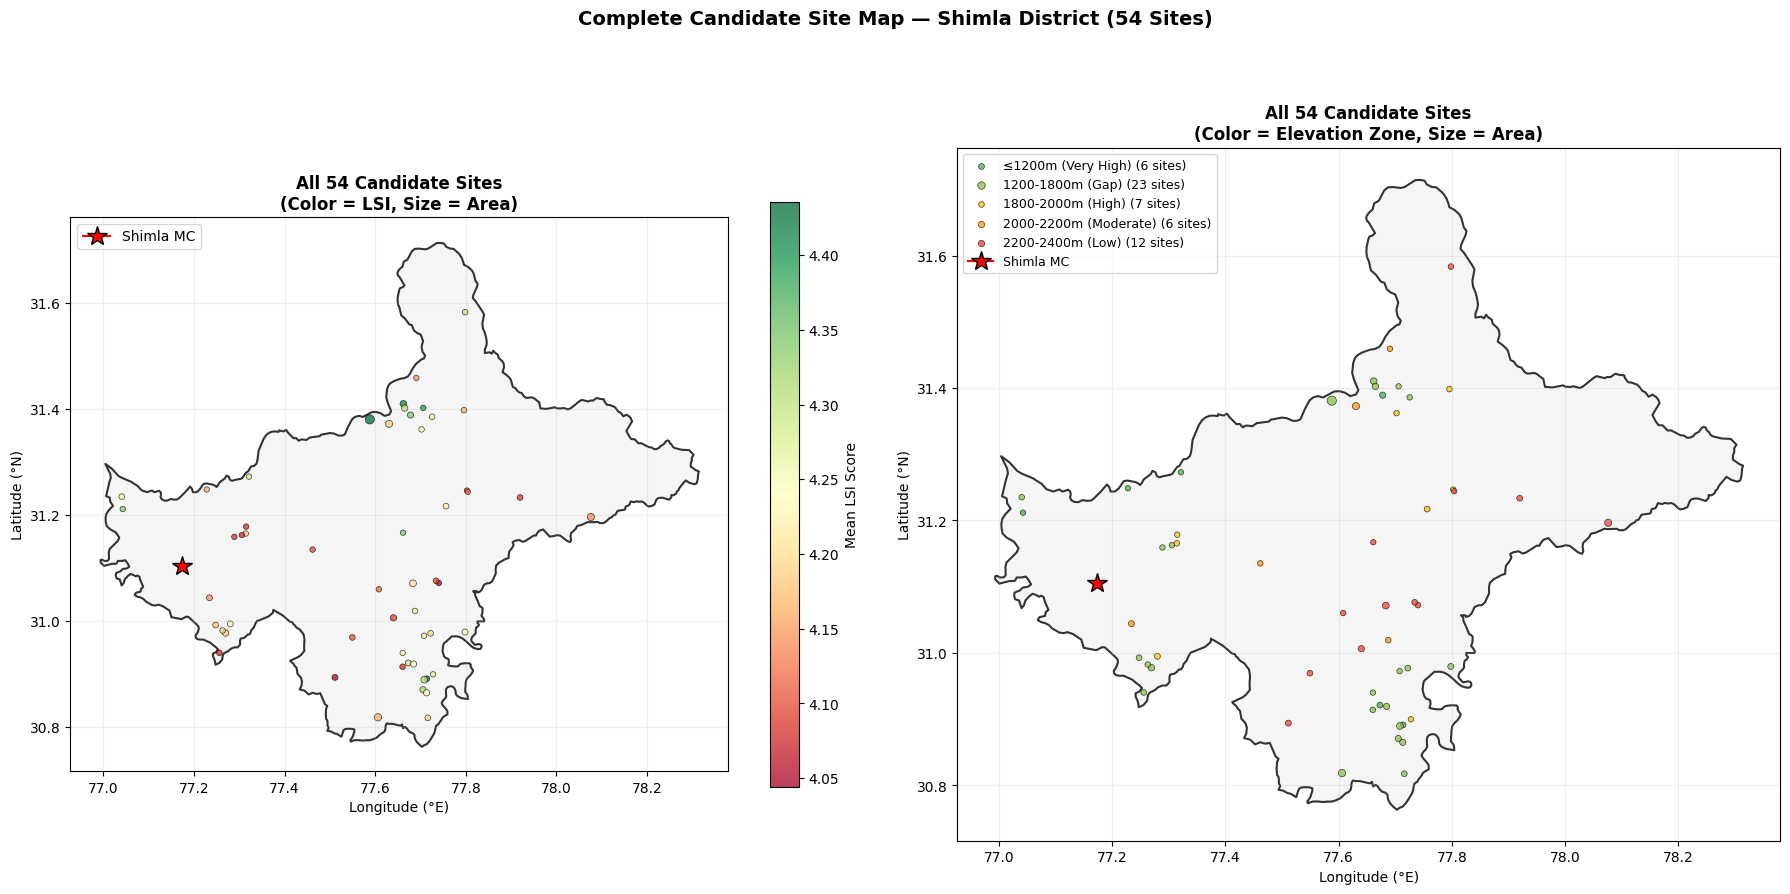


✓ Saved: P5_all_138_sites.png

VIKOR TOP SITES SUMMARY

Top 10 sites by VIKOR Qi:
  Rk      Qi    Area    LSI  Slope   Elev   Road  MC(km)      Lat      Lon
  --------------------------------------------------------------------------------
  1    0.000    14.0  4.427   14.7   1015     69    56.6  30.8915  77.7140
  2    0.064    16.9  4.048   11.6   2354    188    39.7  30.8940  77.5112
  3    0.137    10.1  4.347   14.4   2276    196    46.9  31.1670  77.6613
  4    0.162    17.7  4.241   16.9   1632    447    61.0  30.9795  77.7982
  5    0.163    33.6  4.139   20.2   2210     59    86.4  31.1965  78.0761
  6    0.186    28.0  4.301   18.8   1215    251    56.2  30.8897  77.7084
  7    0.199    19.6  4.316   18.1   1403    117    56.8  30.8708  77.7054
  8    0.223    13.4  4.296   19.8   2221    336    79.7  31.5833  77.7985
  9    0.232    36.2  4.157   13.4   1285     60    52.0  30.8186  77.6060
  10   0.251    14.6  4.195   14.6   1588    569    54.1  30.9770  77.7222

Google M

In [9]:
# ============================================================
# VISUALIZE ALL 138 CANDIDATE SITES FROM CSV
# ============================================================
print("=" * 60)
print("ALL 138 CANDIDATE SITES — COMPLETE VISUALIZATION")
print("=" * 60)

# ---- LOAD RANKED RESULTS ----
# results_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
# all_sites = pd.read_csv(results_path)
# print(f"Total candidate sites: {len(all_sites)}")

results_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
all_sites = pd.read_csv(results_path)
n_sites = len(all_sites)
print(f"Total candidate sites: {n_sites}")
print(f"Loaded from: {results_path}")

# ---- STATISTICS OVERVIEW ----
print(f"\nArea distribution:")
print(f"  Min:    {all_sites['area_ha'].min():.2f} ha")
print(f"  Max:    {all_sites['area_ha'].max():.2f} ha")
print(f"  Mean:   {all_sites['area_ha'].mean():.2f} ha")
print(f"  Median: {all_sites['area_ha'].median():.2f} ha")
print(f"  Total:  {all_sites['area_ha'].sum():.2f} ha ({all_sites['area_ha'].sum()/100:.2f} sq.km)")

print(f"\nLSI distribution:")
print(f"  Min:  {all_sites['mean_lsi'].min():.4f}")
print(f"  Max:  {all_sites['mean_lsi'].max():.4f}")
print(f"  Mean: {all_sites['mean_lsi'].mean():.4f}")

print(f"\nElevation distribution:")
print(f"  Min:  {all_sites['mean_elevation'].min():.0f} m")
print(f"  Max:  {all_sites['mean_elevation'].max():.0f} m")
print(f"  Mean: {all_sites['mean_elevation'].mean():.0f} m")

# ---- CATEGORIZE BY ELEVATION FOR PRACTICAL FEASIBILITY ----
all_sites["elevation_zone"] = pd.cut(
    all_sites["mean_elevation"],
    bins=[0, 1200, 1800, 2000, 2200, 2400],
    labels=["≤1200m (Very High)", "1200-1800m (Gap)", "1800-2000m (High)",
            "2000-2200m (Moderate)", "2200-2400m (Low)"]
)

print(f"\nSites by elevation zone:")
for zone, count in all_sites["elevation_zone"].value_counts().sort_index().items():
    total_area = all_sites[all_sites["elevation_zone"] == zone]["area_ha"].sum()
    print(f"  {zone}: {count} sites ({total_area:.2f} ha)")

# ---- PLOT: ALL 138 SITES ----
shimla_latlon = shimla.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ---- LEFT: All sites colored by LSI ----
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

scatter1 = ax1.scatter(
    all_sites["centroid_lon"], all_sites["centroid_lat"],
    c=all_sites["mean_lsi"], cmap="RdYlGn",
    s=all_sites["area_ha"].clip(upper=200) * 0.5 + 10,  # size proportional to area
    alpha=0.75, edgecolors="black", linewidth=0.5,
    vmin=all_sites["mean_lsi"].min(), vmax=all_sites["mean_lsi"].max()
)

# Mark Shimla MC center
mc_lon, mc_lat = transformer_to_latlon.transform(
    *Transformer.from_crs("EPSG:4326", "EPSG:32643", always_xy=True).transform(77.1734, 31.1048)
)
ax1.plot(77.1734, 31.1048, marker='*', color='red', markersize=15,
         markeredgecolor='black', markeredgewidth=1, label="Shimla MC", zorder=10)

cbar1 = plt.colorbar(scatter1, ax=ax1, shrink=0.7)
cbar1.set_label("Mean LSI Score", fontsize=10)

ax1.set_title(f"All {n_sites} Candidate Sites\n(Color = LSI, Size = Area)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(True, alpha=0.2)

# ---- RIGHT: All sites colored by elevation zone ----
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

zone_colors = {
    "≤1200m (Very High)": "#4CAF50",
    "1200-1800m (Gap)": "#8BC34A",
    "1800-2000m (High)": "#FFC107",
    "2000-2200m (Moderate)": "#FF9800",
    "2200-2400m (Low)": "#F44336",
    ">2400m (Very Low)": "#FF5722"
}
    
for zone, color in zone_colors.items():
    zone_data = all_sites[all_sites["elevation_zone"] == zone]
    if len(zone_data) > 0:
        ax2.scatter(
            zone_data["centroid_lon"], zone_data["centroid_lat"],
            c=color, s=zone_data["area_ha"].clip(upper=200) * 0.5 + 10,
            alpha=0.75, edgecolors="black", linewidth=0.5,
            label=f"{zone} ({len(zone_data)} sites)"
        )

ax2.plot(77.1734, 31.1048, marker='*', color='red', markersize=15,
         markeredgecolor='black', markeredgewidth=1, label="Shimla MC", zorder=10)

ax2.set_title(f"All {len(all_sites)} Candidate Sites\n(Color = Elevation Zone, Size = Area)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=10)
ax2.set_ylabel("Latitude (°N)", fontsize=10)
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.2)

plt.suptitle(f"Complete Candidate Site Map — Shimla District ({n_sites} Sites)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, f"P5_all_{n_sites}_sites.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P5_all_138_sites.png")

# ---- VIKOR TOP-N SUMMARY ----
print(f"\n{'=' * 60}")
print("VIKOR TOP SITES SUMMARY")
print("=" * 60)

# Distance to Shimla MC (informational — both analyses now have this in P4 column,
# but recomputing on lat/lon makes this cell self-contained)
shimla_mc_lat, shimla_mc_lon = 31.1048, 77.1734
all_sites["dist_shimla_mc_km"] = np.sqrt(
    ((all_sites["centroid_lat"] - shimla_mc_lat) * 111.0) ** 2 +
    ((all_sites["centroid_lon"] - shimla_mc_lon) * 111.0 *
     np.cos(np.radians(shimla_mc_lat))) ** 2
)

top_n = min(10, n_sites)
top = all_sites.sort_values("vikor_rank").head(top_n)

print(f"\nTop {top_n} sites by VIKOR Qi:")
print(f"  {'Rk':<3} {'Qi':>6} {'Area':>7} {'LSI':>6} {'Slope':>6} {'Elev':>6} "
      f"{'Road':>6} {'MC(km)':>7} {'Lat':>8} {'Lon':>8}")
print("  " + "-" * 80)
for _, row in top.iterrows():
    print(f"  {int(row['vikor_rank']):<3} {row['Qi']:>6.3f} {row['area_ha']:>7.1f} "
          f"{row['mean_lsi']:>6.3f} {row['mean_slope']:>6.1f} {row['mean_elevation']:>6.0f} "
          f"{row['mean_road_dist']:>6.0f} {row['dist_shimla_mc_km']:>7.1f} "
          f"{row['centroid_lat']:>8.4f} {row['centroid_lon']:>8.4f}")

# Optional: Google Maps URLs for the top 5 — useful for the eyeball-check
# diagnostic discussed earlier (verify each top site is on real serviceable terrain)
print(f"\nGoogle Maps URLs for top 5 (open to verify on satellite):")
for _, row in top.head(5).iterrows():
    print(f"  Rank {int(row['vikor_rank'])}: "
          f"https://www.google.com/maps/@{row['centroid_lat']:.4f},{row['centroid_lon']:.4f},500m/data=!3m1!1e3")

# ============================================================
# REASONING AND METHODOLOGY NOTES
# ============================================================
print(f"\n{'=' * 60}")
print("REASONING AND METHODOLOGY NOTES")
print("=" * 60)
print(f"""
1. WHY VISUALIZE ALL {n_sites} SITES?
   The VIKOR top-15 table only shows the best performers. Plotting
   every candidate reveals the district-level spatial pattern: are
   suitable sites concentrated near Shimla MC or distributed across
   sub-regions? This pattern has direct planning implications under
   the SWM Rules 2026 hilly-region provisions, which encourage
   decentralised processing in mountain districts.

2. WHY CATEGORIZE BY ELEVATION (DESPITE THE 2400m P4 CAP)?
   The P4 elevation constraint enforces the paper's >2400m hard cut,
   but the paper also defines four further suitability bands within
   the feasible range (≤1200m Very High, 1800-2000m High, 2000-2200m
   Moderate, 2200-2400m Low). Plotting by zone shows where each
   candidate sits within those bands — the LSI score alone obscures
   this because elevation is one of eleven inputs. Sites in the
   "Very High" elevation band (≤1200m) are operationally superior
   for year-round access in Himalayan terrain.

3. DISTANCE TO SHIMLA MC AS DIAGNOSTIC:
   The dist_shimla_mc_km column is informational, not a ranking
   criterion. It surfaces the scope-difference between Analysis A
   (whole district, candidates may be 30+ km from MC) and Analysis
   B (30km cap, candidates are 10-30 km from MC). This is the same
   axis the discussion section uses to compare against the paper's
   Kiargiri/Baboloo/Karog/Phayal Road sites near the MC.

4. THE GOOGLE MAPS URLS:
   Provided for satellite-imagery sanity check on the top 5. Useful
   to confirm a 90m-from-road site really is at the edge of a
   serviceable road (not a forest track), that the cluster doesn't
   overlap with protected-area boundaries, and that the surrounding
   land use is plausible for landfill development.
""")

# ML 

PHASE B — ML-BASED SITE IDENTIFICATION

STEP B1: EXTRACT HIGH SUITABILITY ZONES FROM ML MAP

Loading ML suitability maps...
  ML classified raster shape: (10553, 12545)
  Unique classes: [1 2 3 4 5]

Assigning ML predictions to dataset pixels...
  ML predictions assigned to 51,423,700 pixels

Class distribution comparison:
  Class                 MCDA Pixels   MCDA %      ML Pixels     ML %
  -----------------------------------------------------------------
  1 Very Low            1,060,985    2.06%        966,721    1.88%
  2 Low                13,055,064   25.39%     12,975,758   25.23%
  3 Moderate           31,455,011   61.17%     31,731,598   61.71%
  4 High                5,826,106   11.33%      5,720,176   11.12%
  5 Very High              26,534    0.05%         29,447    0.06%

ML High suitability pixels extracted:
  Class 4 (High):       5,720,176 pixels
  Class 5 (Very High):     29,447 pixels
  Total:                5,749,623 pixels
  Area:                574.96 sq.km
  % o

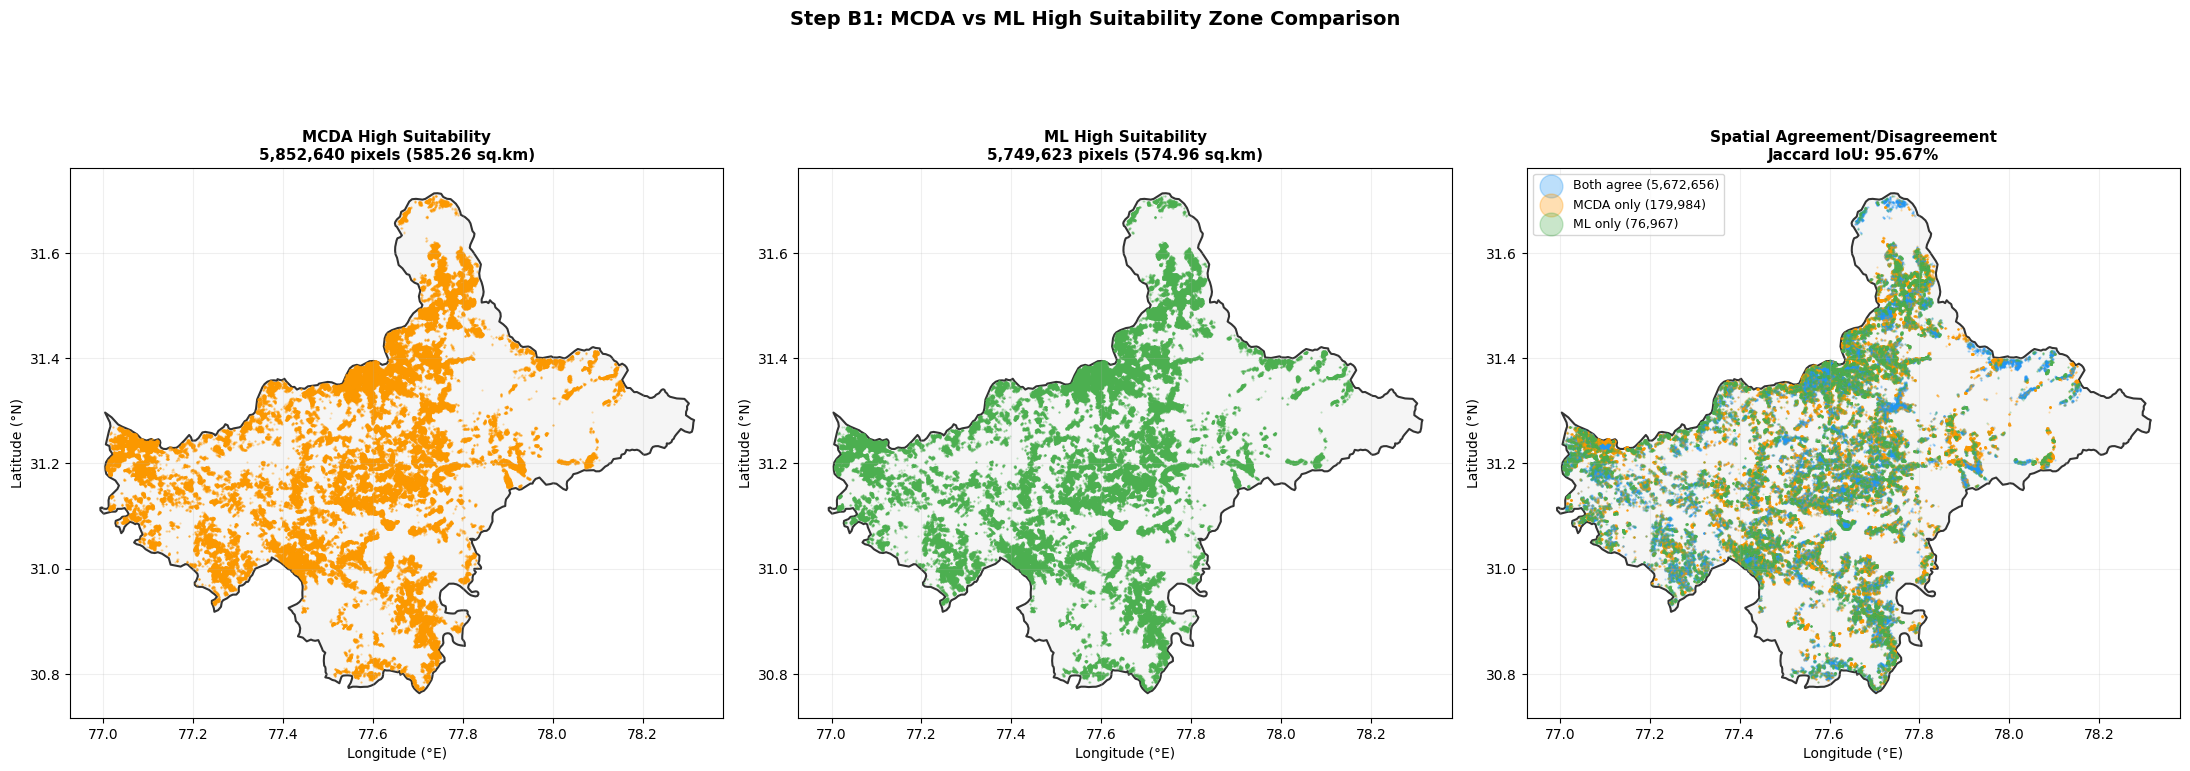


✓ Saved: B1_MCDA_vs_ML_high_suitability.png

REASONING AND METHODOLOGY NOTES

1. WHY EXTRACT FROM ML MAP SEPARATELY?
   The MCDA pipeline (Phase C) extracted Class 4+5 from the AHP-derived
   LSI map. This pipeline extracts from the ML-predicted suitability map.
   Even though ML achieves 98.11% pixel agreement with MCDA, the 1.89%
   disagreement may produce different candidate zones — some areas that
   MCDA classified as "High" might be "Moderate" in ML, and vice versa.
   These differences are where ML's data-driven learning diverges from
   expert judgment, and comparing them is the core research contribution.

2. WHY THE JACCARD INDEX?
   Simple accuracy or overlap percentage can be misleading when zones
   have different sizes. Jaccard Index (Intersection over Union) measures
   spatial agreement accounting for both shared and unique areas. A Jaccard
   of 1.0 means perfect spatial overlap; 0.0 means completely different
   zones. For landfill siting, even small spatial disagre

In [10]:
# ============================================================
# PHASE B: ML-BASED SITE IDENTIFICATION
# ============================================================
# This pipeline mirrors the MCDA pipeline (P1–P5) but operates
# on the ML-predicted suitability map instead of the AHP-derived
# LSI map. The key difference: ML learned feature importances
# from data, while MCDA used expert-assigned AHP weights.
# At the end, we compare which sites each method recommends.
# ============================================================

# ============================================================
# STEP B1: EXTRACT HIGH SUITABILITY ZONES FROM ML MAP
# ============================================================
print("=" * 60)
print("PHASE B — ML-BASED SITE IDENTIFICATION")
print("=" * 60)
print("\nSTEP B1: EXTRACT HIGH SUITABILITY ZONES FROM ML MAP")
print("=" * 60)

# ---- LOAD ML SUITABILITY CLASSIFICATIONS ----
# The ML suitability map was generated in Step 7 using XGBoost
# trained on subsampled spatial split (~700K pixels) and then
# predicted across all 51.4M pixels of the district.
ml_classified_path = r"D:\Important\Semester\Semester X\MTP\LSI\ML_suitability_classified.tif"
ml_continuous_path = r"D:\Important\Semester\Semester X\MTP\LSI\ML_suitability_continuous.tif"

print("\nLoading ML suitability maps...")
with rasterio.open(ml_classified_path) as src:
    ml_classified_raster = src.read(1)
    print(f"  ML classified raster shape: {ml_classified_raster.shape}")
    print(f"  Unique classes: {np.unique(ml_classified_raster[ml_classified_raster > 0])}")

with rasterio.open(ml_continuous_path) as src:
    ml_continuous_raster = src.read(1)

# ---- ASSIGN ML PREDICTIONS TO FULL DATASET ----
# df was loaded in Step P1 with pixel_row and pixel_col
print("\nAssigning ML predictions to dataset pixels...")
rows = df["pixel_row"].values
cols = df["pixel_col"].values

df["ml_classified"] = ml_classified_raster[rows, cols]
df["ml_continuous"] = ml_continuous_raster[rows, cols]

print(f"  ML predictions assigned to {len(df):,} pixels")

# ---- ML CLASS DISTRIBUTION (compare with MCDA) ----
print(f"\nClass distribution comparison:")
print(f"  {'Class':<18} {'MCDA Pixels':>14} {'MCDA %':>8} {'ML Pixels':>14} {'ML %':>8}")
print("  " + "-" * 65)
for cls in [1, 2, 3, 4, 5]:
    mcda_count = (df["lsi_classified"] == cls).sum()
    ml_count = (df["ml_classified"] == cls).sum()
    mcda_pct = (mcda_count / len(df)) * 100
    ml_pct = (ml_count / len(df)) * 100
    print(f"  {cls} {class_labels[cls]:<14} {mcda_count:>14,} {mcda_pct:>7.2f}% {ml_count:>14,} {ml_pct:>7.2f}%")

# ---- EXTRACT CLASS 4 + 5 FROM ML MAP ----
df_ml_high = df[df["ml_classified"].isin([4, 5])].copy().reset_index(drop=True)

print(f"\nML High suitability pixels extracted:")
print(f"  Class 4 (High):      {(df_ml_high['ml_classified'] == 4).sum():>10,} pixels")
print(f"  Class 5 (Very High): {(df_ml_high['ml_classified'] == 5).sum():>10,} pixels")
print(f"  Total:               {len(df_ml_high):>10,} pixels")
print(f"  Area:                {len(df_ml_high) * 100 / 1_000_000:.2f} sq.km")
print(f"  % of district:       {len(df_ml_high) / len(df) * 100:.2f}%")

# ---- COMPARE SPATIAL OVERLAP WITH MCDA HIGH SUITABILITY ----
# How many pixels are "High" in both MCDA and ML?
both_high = df[(df["lsi_classified"].isin([4, 5])) & (df["ml_classified"].isin([4, 5]))]
mcda_only = df[(df["lsi_classified"].isin([4, 5])) & (~df["ml_classified"].isin([4, 5]))]
ml_only = df[(~df["lsi_classified"].isin([4, 5])) & (df["ml_classified"].isin([4, 5]))]

print(f"\nSpatial overlap of high suitability zones:")
print(f"  Both MCDA & ML agree (High):     {len(both_high):>10,} pixels ({len(both_high)*100/1_000_000:.2f} sq.km)")
print(f"  MCDA High but ML disagrees:      {len(mcda_only):>10,} pixels ({len(mcda_only)*100/1_000_000:.2f} sq.km)")
print(f"  ML High but MCDA disagrees:      {len(ml_only):>10,} pixels ({len(ml_only)*100/1_000_000:.2f} sq.km)")

total_union = len(both_high) + len(mcda_only) + len(ml_only)
jaccard = len(both_high) / total_union if total_union > 0 else 0
print(f"  Jaccard similarity (IoU):        {jaccard:.4f} ({jaccard*100:.2f}%)")

# ---- FEATURE STATISTICS OF ML HIGH SUITABILITY ZONES ----
print(f"\nFeature characteristics of ML high suitability zones:")
print(f"  {'Feature':<18} {'Mean':>10} {'Min':>10} {'Max':>10}")
print("  " + "-" * 50)
for col in feature_cols:
    print(f"  {col:<18} {df_ml_high[col].mean():>10.2f} {df_ml_high[col].min():>10.2f} {df_ml_high[col].max():>10.2f}")

print(f"\n  ML continuous: {df_ml_high['ml_continuous'].mean():.4f} mean, "
      f"{df_ml_high['ml_continuous'].min():.4f} min, {df_ml_high['ml_continuous'].max():.4f} max")

# ---- VISUALIZATION: MCDA vs ML HIGH SUITABILITY ZONES ----
print("\nGenerating comparison visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Panel 1: MCDA High Suitability
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)
mcda_high_pixels = df[df["lsi_classified"].isin([4, 5])]
np.random.seed(42)
sample_idx = np.random.choice(len(mcda_high_pixels), size=min(200_000, len(mcda_high_pixels)), replace=False)
m_x = raster_transform.c + (mcda_high_pixels.iloc[sample_idx]["pixel_col"].values * raster_transform.a)
m_y = raster_transform.f + (mcda_high_pixels.iloc[sample_idx]["pixel_row"].values * raster_transform.e)
m_lon, m_lat = transformer_to_latlon.transform(m_x, m_y)
ax1.scatter(m_lon, m_lat, c="#FF9800", s=0.3, alpha=0.3)
ax1.set_title(f"MCDA High Suitability\n{len(mcda_high_pixels):,} pixels ({len(mcda_high_pixels)*100/1_000_000:.2f} sq.km)",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.grid(True, alpha=0.2)

# Panel 2: ML High Suitability
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)
sample_idx2 = np.random.choice(len(df_ml_high), size=min(200_000, len(df_ml_high)), replace=False)
ml_x = raster_transform.c + (df_ml_high.iloc[sample_idx2]["pixel_col"].values * raster_transform.a)
ml_y = raster_transform.f + (df_ml_high.iloc[sample_idx2]["pixel_row"].values * raster_transform.e)
ml_lon, ml_lat = transformer_to_latlon.transform(ml_x, ml_y)
ax2.scatter(ml_lon, ml_lat, c="#4CAF50", s=0.3, alpha=0.3)
ax2.set_title(f"ML High Suitability\n{len(df_ml_high):,} pixels ({len(df_ml_high)*100/1_000_000:.2f} sq.km)",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Longitude (°E)")
ax2.set_ylabel("Latitude (°N)")
ax2.grid(True, alpha=0.2)

# Panel 3: Overlap/Disagreement
ax3 = axes[2]
shimla_latlon.plot(ax=ax3, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Both agree
if len(both_high) > 0:
    b_sample = both_high.sample(n=min(100_000, len(both_high)), random_state=42)
    b_x = raster_transform.c + (b_sample["pixel_col"].values * raster_transform.a)
    b_y = raster_transform.f + (b_sample["pixel_row"].values * raster_transform.e)
    b_lon, b_lat = transformer_to_latlon.transform(b_x, b_y)
    ax3.scatter(b_lon, b_lat, c="#2196F3", s=0.3, alpha=0.3, label=f"Both agree ({len(both_high):,})")

# MCDA only
if len(mcda_only) > 0:
    mo_sample = mcda_only.sample(n=min(50_000, len(mcda_only)), random_state=42)
    mo_x = raster_transform.c + (mo_sample["pixel_col"].values * raster_transform.a)
    mo_y = raster_transform.f + (mo_sample["pixel_row"].values * raster_transform.e)
    mo_lon, mo_lat = transformer_to_latlon.transform(mo_x, mo_y)
    ax3.scatter(mo_lon, mo_lat, c="#FF9800", s=0.3, alpha=0.3, label=f"MCDA only ({len(mcda_only):,})")

# ML only
if len(ml_only) > 0:
    mlo_sample = ml_only.sample(n=min(50_000, len(ml_only)), random_state=42)
    mlo_x = raster_transform.c + (mlo_sample["pixel_col"].values * raster_transform.a)
    mlo_y = raster_transform.f + (mlo_sample["pixel_row"].values * raster_transform.e)
    mlo_lon, mlo_lat = transformer_to_latlon.transform(mlo_x, mlo_y)
    ax3.scatter(mlo_lon, mlo_lat, c="#4CAF50", s=0.3, alpha=0.3, label=f"ML only ({len(ml_only):,})")

ax3.set_title(f"Spatial Agreement/Disagreement\nJaccard IoU: {jaccard:.2%}",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Longitude (°E)")
ax3.set_ylabel("Latitude (°N)")
ax3.legend(loc="upper left", fontsize=9, markerscale=30)
ax3.grid(True, alpha=0.2)

plt.suptitle("Step B1: MCDA vs ML High Suitability Zone Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "B1_MCDA_vs_ML_high_suitability.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: B1_MCDA_vs_ML_high_suitability.png")

# Free raster memory
del ml_classified_raster, ml_continuous_raster
gc.collect()

# ============================================================
# REASONING AND METHODOLOGY NOTES
# ============================================================
print(f"\n{'=' * 60}")
print("REASONING AND METHODOLOGY NOTES")
print("=" * 60)
print("""
1. WHY EXTRACT FROM ML MAP SEPARATELY?
   The MCDA pipeline (Phase C) extracted Class 4+5 from the AHP-derived
   LSI map. This pipeline extracts from the ML-predicted suitability map.
   Even though ML achieves 98.11% pixel agreement with MCDA, the 1.89%
   disagreement may produce different candidate zones — some areas that
   MCDA classified as "High" might be "Moderate" in ML, and vice versa.
   These differences are where ML's data-driven learning diverges from
   expert judgment, and comparing them is the core research contribution.

2. WHY THE JACCARD INDEX?
   Simple accuracy or overlap percentage can be misleading when zones
   have different sizes. Jaccard Index (Intersection over Union) measures
   spatial agreement accounting for both shared and unique areas. A Jaccard
   of 1.0 means perfect spatial overlap; 0.0 means completely different
   zones. For landfill siting, even small spatial disagreements can mean
   different candidate sites, so this metric matters.

3. WHAT THE CLASS DISTRIBUTION COMPARISON REVEALS:
   If ML produces more Class 4+5 pixels than MCDA, ML is "more generous"
   in identifying suitable land — meaning the ML model found additional
   patterns that push borderline areas into the suitable category. If ML
   produces fewer, it is more conservative. The direction and magnitude
   of this difference reveals whether ML and MCDA fundamentally agree
   on what makes land suitable, or whether they weight criteria differently
   enough to change the suitability boundary.

4. THE OVERLAP MAP IS A KEY PUBLICATION FIGURE:
   The three-panel comparison (MCDA zones / ML zones / agreement map)
   visually demonstrates where the two methods agree and disagree. Areas
   where both methods independently identify high suitability are the
   strongest candidates — they're supported by both expert judgment and
   data-driven analysis. Areas identified by only one method warrant
   investigation into which criterion caused the disagreement.
""")

In [11]:
# ============================================================
# B1.5 — DIAGNOSTIC: IS THE DISAGREEMENT REGIONAL OR FRAGMENTED?
# ============================================================
# Counts how many separate connected patches the MCDA-only and
# ML-only disagreement pixels form. Tells us whether Phase B will
# produce candidate sites genuinely different from Phase C, or
# whether the disagreement gets filtered out by the 10-ha minimum
# area threshold in B3.
#
# Interpretation:
#   Few large patches  → regional disagreement, B2-B5 will yield
#                        novel candidates worth comparing
#   Many tiny patches  → fragmented edge noise, B3 area filter
#                        will eliminate most disagreement
# ============================================================
from scipy import ndimage

print("=" * 60)
print("B1.5 — CONNECTED-COMPONENTS DIAGNOSTIC ON DISAGREEMENT")
print("=" * 60)

# Recompute disagreement masks (in case kernel was restarted between cells)
mcda_only_mask = (df["lsi_classified"].isin([4, 5])) & (~df["ml_classified"].isin([4, 5]))
ml_only_mask   = (~df["lsi_classified"].isin([4, 5])) & (df["ml_classified"].isin([4, 5]))

mcda_only_df = df[mcda_only_mask]
ml_only_df   = df[ml_only_mask]

print(f"\nDisagreement pixel counts:")
print(f"  MCDA-only High (MCDA says High, ML disagrees): {len(mcda_only_df):>8,} pixels")
print(f"  ML-only   High (ML says High, MCDA disagrees): {len(ml_only_df):>8,} pixels")

# ---- Build binary rasters of disagreement zones ----
H, W = raster_height, raster_width
structure = np.ones((3, 3), dtype=np.int8)   # 8-connectivity, same as P2/P4

mcda_only_raster = np.zeros((H, W), dtype=np.int8)
mcda_only_raster[mcda_only_df["pixel_row"].values,
                 mcda_only_df["pixel_col"].values] = 1
_, n_mcda_components = ndimage.label(mcda_only_raster, structure=structure)

ml_only_raster = np.zeros((H, W), dtype=np.int8)
ml_only_raster[ml_only_df["pixel_row"].values,
               ml_only_df["pixel_col"].values] = 1
_, n_ml_components = ndimage.label(ml_only_raster, structure=structure)

# ---- Component-size distributions ----
def component_size_summary(raster, n_components, label):
    if n_components == 0:
        print(f"\n  {label}: no components found")
        return
    labeled, _ = ndimage.label(raster, structure=structure)
    _, sizes = np.unique(labeled[labeled > 0], return_counts=True)
    sizes_ha = sizes * 100 / 10_000   # 100 sq.m per pixel → hectares
    over_1ha    = (sizes_ha >= 1).sum()
    over_5ha    = (sizes_ha >= 5).sum()
    over_10ha   = (sizes_ha >= 10).sum()   # B3 threshold
    print(f"\n  {label}:")
    print(f"    Total connected patches:          {n_components:>8,}")
    print(f"    Median patch size:                {np.median(sizes_ha):>8.3f} ha")
    print(f"    Mean patch size:                  {np.mean(sizes_ha):>8.3f} ha")
    print(f"    Largest patch:                    {sizes_ha.max():>8.2f} ha")
    print(f"    Patches >= 1  ha:                 {over_1ha:>8,}")
    print(f"    Patches >= 5  ha:                 {over_5ha:>8,}")
    print(f"    Patches >= 10 ha (B3 threshold):  {over_10ha:>8,}")

component_size_summary(mcda_only_raster, n_mcda_components, "MCDA-only disagreement")
component_size_summary(ml_only_raster,   n_ml_components,   "ML-only disagreement")

# ---- Verdict ----
print(f"\n{'=' * 60}")
print("VERDICT")
print("=" * 60)

# Count how many disagreement patches would survive the 10ha filter
labeled_mcda, _ = ndimage.label(mcda_only_raster, structure=structure)
labeled_ml,   _ = ndimage.label(ml_only_raster,   structure=structure)
_, sz_mcda = np.unique(labeled_mcda[labeled_mcda > 0], return_counts=True) \
             if n_mcda_components > 0 else (None, np.array([]))
_, sz_ml   = np.unique(labeled_ml[labeled_ml > 0],   return_counts=True) \
             if n_ml_components   > 0 else (None, np.array([]))

mcda_survivors = (sz_mcda * 100 / 10_000 >= 10).sum() if len(sz_mcda) else 0
ml_survivors   = (sz_ml   * 100 / 10_000 >= 10).sum() if len(sz_ml)   else 0

print(f"\nDisagreement patches that would survive the 10-ha filter (B3):")
print(f"  MCDA-only: {mcda_survivors} patches")
print(f"  ML-only:   {ml_survivors} patches")

if (mcda_survivors + ml_survivors) >= 5:
    print(f"\n  → REGIONAL disagreement. Phase B will produce candidate sites")
    print(f"    genuinely different from Phase C. Continue with B2-B5; expect")
    print(f"    real differences in the final ML-5 comparison.")
elif (mcda_survivors + ml_survivors) >= 1:
    print(f"\n  → MIXED. Some regional disagreement survives the area filter,")
    print(f"    but only a handful of patches. Phase B will mostly mirror")
    print(f"    Phase C with a few additions/removals.")
else:
    print(f"\n  → FRAGMENTED edge noise. Disagreement patches are too small")
    print(f"    to survive the 10-ha filter. Phase B candidates will be")
    print(f"    essentially a subset of Phase C with minor VIKOR rank")
    print(f"    reshuffling due to SHAP weights. Run B2-B5 for completeness")
    print(f"    but frame ML-5 modestly: 'ML and MCDA converge on the same")
    print(f"    candidate pool; the comparison reduces to weighting effects.'")

# Free raster memory
del mcda_only_raster, ml_only_raster, labeled_mcda, labeled_ml
gc.collect()

# ============================================================
# REASONING NOTE
# ============================================================
print(f"""
WHY THIS DIAGNOSTIC RUNS BEFORE B2:
  B2 will cluster the full ML high-suitability pool (~5.75M pixels)
  and B3 will keep only clusters >= 10 ha. The vast majority of
  those clusters will overlap with MCDA's clusters because B1's
  Jaccard is 95.67%. The interesting question for the dissertation
  is whether the 4.33% disagreement contributes any clusters that
  ARE >= 10 ha and therefore survive B3 to become candidates that
  are unique to one method or the other.

  This cell answers that question directly. The verdict tells you
  what to expect from B2-B5 and how to frame the ML-5 comparison
  in your report — before you commit two more hours of pipeline
  work to find out.
""")

B1.5 — CONNECTED-COMPONENTS DIAGNOSTIC ON DISAGREEMENT

Disagreement pixel counts:
  MCDA-only High (MCDA says High, ML disagrees):  179,984 pixels
  ML-only   High (ML says High, MCDA disagrees):   76,967 pixels

  MCDA-only disagreement:
    Total connected patches:            46,181
    Median patch size:                   0.010 ha
    Mean patch size:                     0.039 ha
    Largest patch:                       19.10 ha
    Patches >= 1  ha:                      154
    Patches >= 5  ha:                        3
    Patches >= 10 ha (B3 threshold):         1

  ML-only disagreement:
    Total connected patches:            28,086
    Median patch size:                   0.010 ha
    Mean patch size:                     0.027 ha
    Largest patch:                        4.68 ha
    Patches >= 1  ha:                       38
    Patches >= 5  ha:                        0
    Patches >= 10 ha (B3 threshold):         0

VERDICT

Disagreement patches that would survive the 10-ha

This is the fragmented edge noise scenario, dressed up as "MIXED" by the verdict logic. Let me explain plainly.
What the numbers tell you
MCDA-only disagreement: 46,181 patches. Median size 0.01 ha (a single pixel — 10m × 10m). Mean 0.039 ha. Of those 46,181 patches, only 1 is large enough to survive your 10-ha filter.
ML-only disagreement: 28,086 patches. Median 0.01 ha. Largest patch is 4.68 ha. Zero patches survive the 10-ha filter.
What this means physically: the 4.33% spatial disagreement between ML and MCDA is almost entirely single-pixel speckle along class boundaries. Imagine the boundary between Class 3 and Class 4 zones on a map — when you compute suitability two different ways, individual pixels right on that boundary flip back and forth. ML says one pixel is Class 4, MCDA says it's Class 3. The pixel next to it goes the other way. There's no coherent regional area where ML thinks "yes, suitable" and MCDA thinks "no."
The verdict text says "MIXED" because the threshold I set (≥5 surviving patches) was generous. With 1 surviving patch on the MCDA side and 0 on the ML side, the honest reading is fragmented.
What this means for your dissertation
Phase B is going to produce nearly the same candidate sites as Phase C. After your 10-ha area filter in B3, the ML candidate pool will be a near-identical subset of the MCDA candidate pool. There will be at most one cluster unique to MCDA and zero clusters unique to ML.
The remaining differences in your final ML-5 comparison will come from:

VIKOR rank reshuffling — same candidates, different rankings, because SHAP weights differ from AHP weights.
Possible cluster boundary changes — the same "region" might be one big cluster in MCDA and split into two smaller clusters in ML if a boundary pixel flipped, or vice versa. Minor.

That's it. The "ML reveals novel landfill sites" framing is dead. The actual finding is more measured.
How to frame this in the report
The honest framing — and it's still publishable, don't worry — is:
"Despite divergent feature-importance rankings between ML and AHP (LULC: AHP rank 3 → SHAP rank 10; road distance: AHP rank 5 → SHAP rank 1), the resulting suitability maps converge on essentially the same high-suitability geography (Jaccard 95.67%, no regional disagreement zones large enough to constitute independent candidate sites). The methodological divergence is therefore expressed not in which areas are identified as suitable, but in how those areas are ranked once candidate sites are extracted."
This is actually a stronger, more interesting finding than "the methods disagree." It says:

Expert weights and data-driven weights produce different internal explanations
But geographic suitability is robust to that internal disagreement
The action moves to the ranking step (VIKOR), where the two weight schemes will produce different orderings of the same candidate sites

What to do for B2-B5
Do them anyway. You need the full ML pipeline to make the comparison concrete. But:

Don't expect novel sites. Expect the same candidate clusters with possibly different boundaries.
Skip ML-5's "set overlap" metric as a primary finding — you already know it'll be ~95-100%. Run it for completeness but don't lead with it.
The Spearman rank correlation and the Mann-Whitney landslide test become your primary ML-5 findings. These test whether the two weight schemes rank the same candidate set differently. That's where your story lives now.
Add the third weights-only ranking I mentioned earlier. It's no longer optional — it's now the cleanest way to show your finding. Take the MCDA candidate pool, rank it twice (AHP weights vs SHAP weights), and report the rank correlation. This isolates the weighting effect from any pool effect, and given your B1.5 result, the pool effect is essentially zero anyway. The weights-only comparison is the real comparison.

What to write up from B1 + B1.5 right now
Three sentences for the report:

ML and MCDA produce highly congruent high-suitability maps (Jaccard 95.67%), with disagreement confined to single-pixel speckle along classification boundaries.
The 4.33% disagreement consists of 74,267 connected patches with median size 0.01 ha; only 1 patch (MCDA-only) and 0 patches (ML-only) exceed the 10-hectare minimum area threshold for landfill viability.
The two methods therefore identify essentially the same candidate site pool, and the methodological comparison reduces to whether AHP-derived and SHAP-derived weights rank that shared pool in the same order.

That last sentence is your transition into ML-4 and ML-5. It tells the reader exactly what you're going to test and why.
My direct recommendation
Proceed to B2-B5 for completeness, but reframe your dissertation chapter now around "weight-driven ranking divergence on a shared candidate pool" rather than "ML reveals different sites." This is honest to your data and still represents a meaningful contribution — you've shown that geographic suitability mapping is robust to expert-vs-data-driven weighting in this terrain, which is itself a useful finding for practitioners deciding which method to invest in.

PHASE B — ML VIKOR RANKING (SHAP weights, same pool)
Loaded 54 candidate sites (same pool as MCDA)

SHAP weights sum: 1.0000

Weight comparison — AHP vs SHAP:
  Code  Criterion                  AHP    SHAP     Diff  AHP Rank  SHAP Rank
  ------------------------------------------------------------------------
  LSP   mean_landslide_dist      0.162   0.117  -0.045 ↓       1 → 5     
  LULC  mean_lulc                0.122   0.013  -0.109 ↓       3 → 10    
  WBP   mean_water_dist          0.061   0.018  -0.043 ↓       8 → 9     
  BUP   mean_builtup_dist        0.084   0.144  +0.060 ↑       6 → 3     
  LNP   mean_lineament_dist      0.056   0.102  +0.046 ↑       9 → 7     
  RAIL  mean_rail_dist           0.041   0.007  -0.034 ↓      11 → 11    
  GSL   mean_slope               0.138   0.133  -0.005 ≈       2 → 4     
  GEL   mean_elevation           0.114   0.146  +0.032 ↑       4 → 2     
  ROAD  mean_road_dist           0.095   0.153  +0.058 ↑       5 → 1     
  LNV   mean_land_value

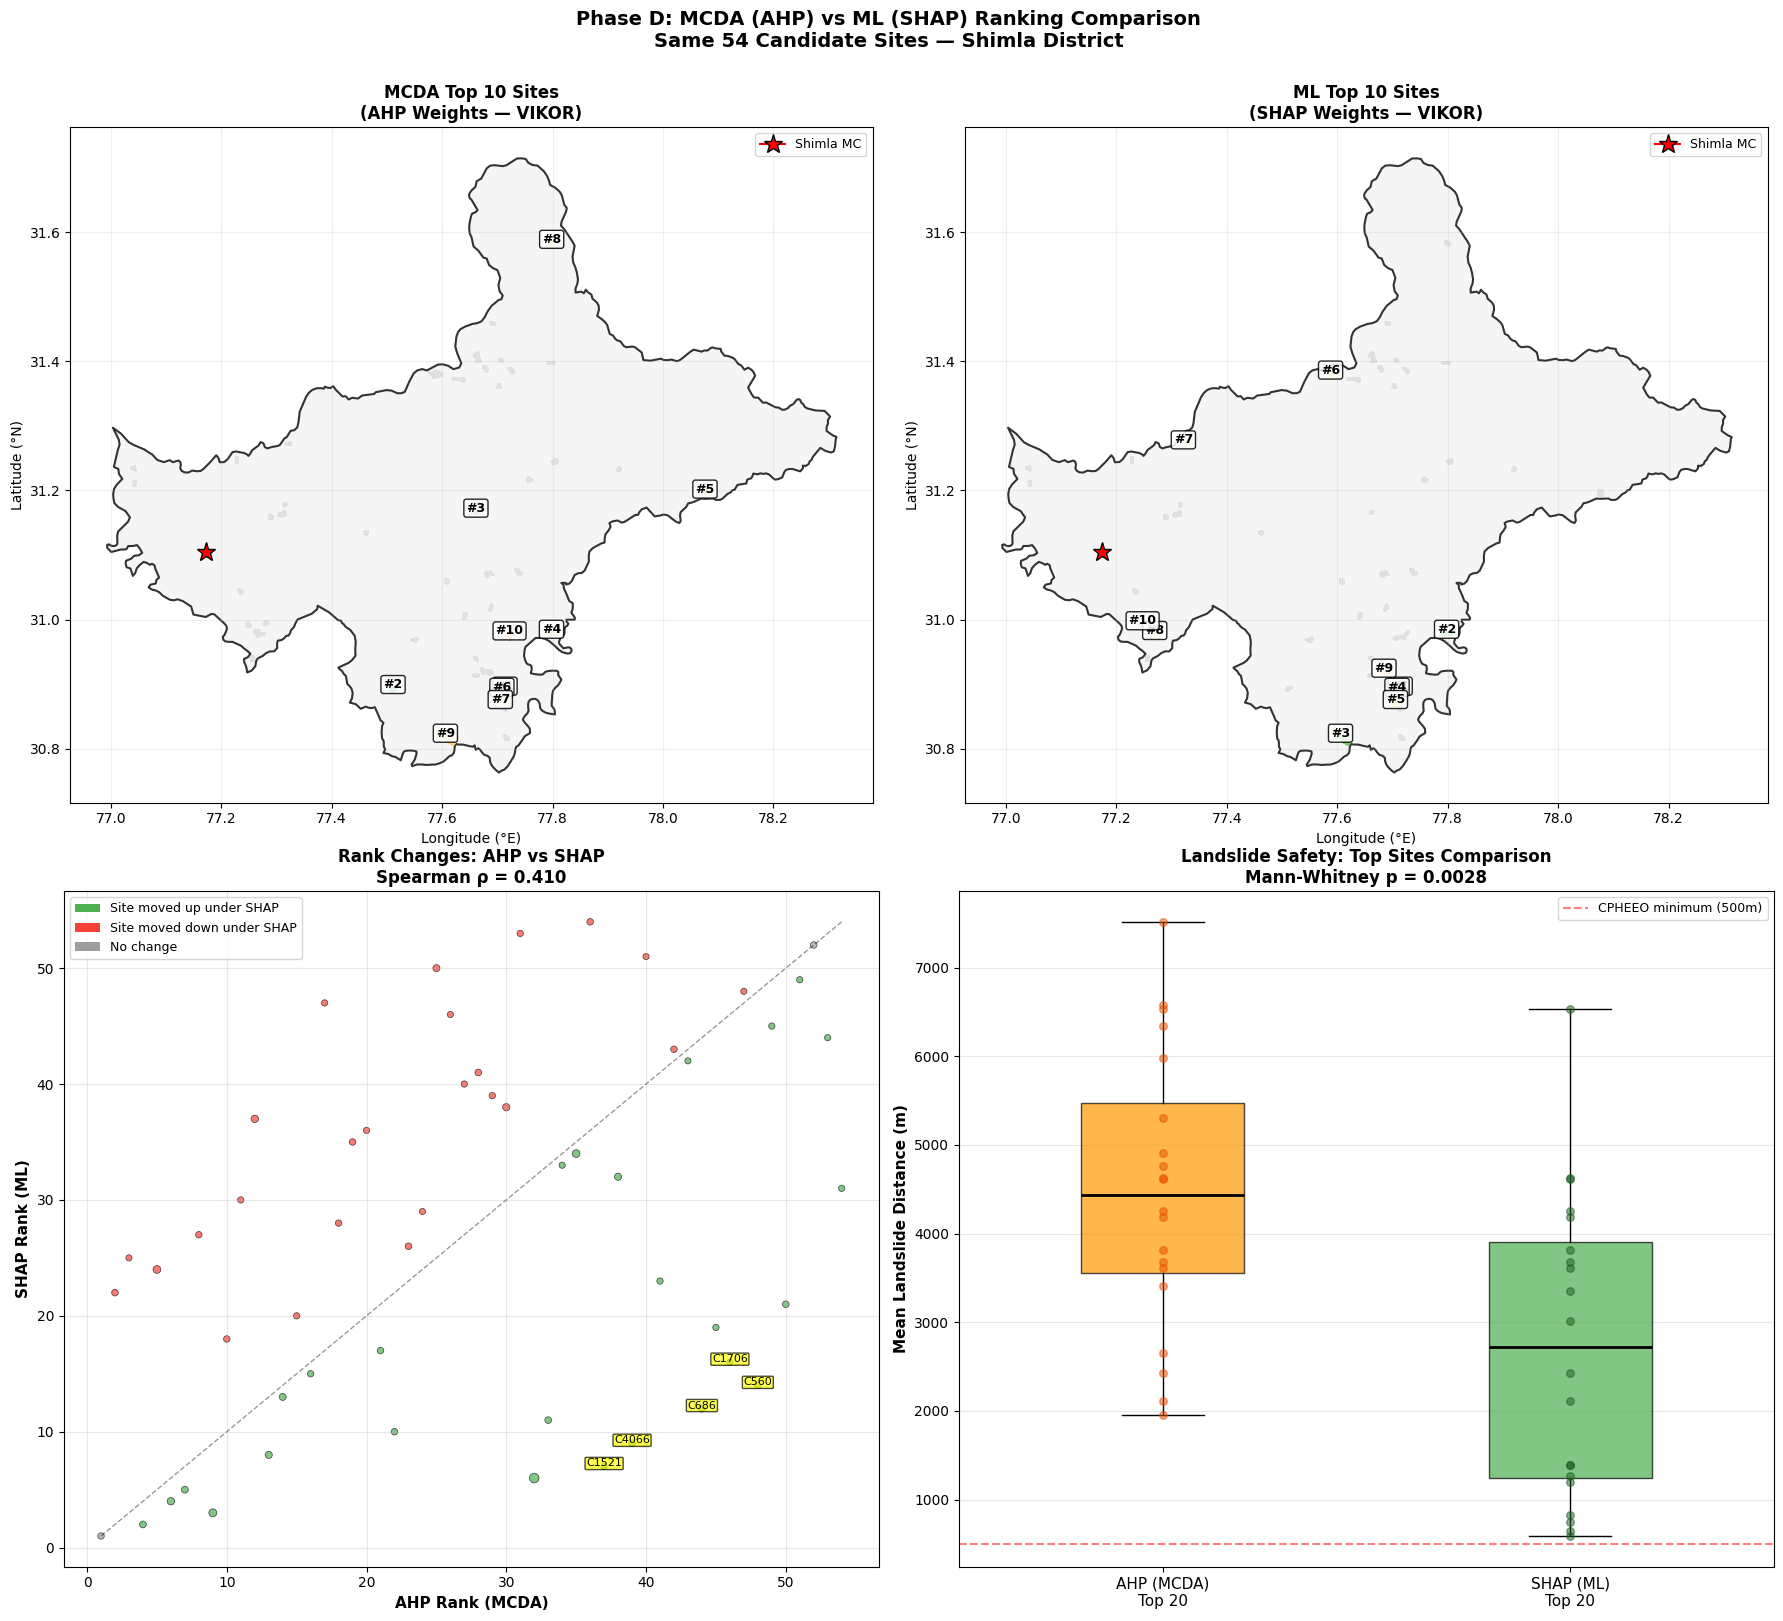


✓ Saved: D_AHP_vs_SHAP_ranking_comparison.png

REASONING AND METHODOLOGY NOTES

1. WHY OPTION 1 (SAME POOL, DIFFERENT WEIGHTS)?
   B1.5 showed that ML and MCDA high-suitability zones have 95.67%
   Jaccard overlap, with only 1 patch of unique-to-MCDA pixels
   exceeding the 10-ha minimum and zero unique-to-ML patches.
   Running separate clustering pipelines would produce nearly
   identical candidate pools — any differences would reflect
   edge-noise classification differences, not meaningful spatial
   divergence. Option 1 holds the candidate pool constant and
   isolates the weight effect as the only variable. This is a
   controlled experiment: same candidates, same criteria,
   same VIKOR formula — only weights change.

2. WHY SHAP MEAN ABSOLUTE VALUES AS WEIGHTS?
   Three options existed: XGBoost gain-based importance, permutation
   importance, and SHAP mean absolute values. SHAP is preferred because:
   (a) Shapley values have a solid game-theoretic foundation
   (b) They acc

In [12]:
# ============================================================
# PHASE B — OPTION 1: ML VIKOR RANKING
# ============================================================
# Same 138 candidate clusters as MCDA pipeline (Phase C).
# Only difference: SHAP-derived weights replace AHP weights.
# This isolates the weight effect — same candidates, different
# importance structure, different ranking outcome.
# ============================================================
print("=" * 60)
print("PHASE B — ML VIKOR RANKING (SHAP weights, same pool)")
print("=" * 60)

# ---- LOAD SAME CANDIDATE STATS ----
stats_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
sites_ml = pd.read_csv(stats_path)
print(f"Loaded {len(sites_ml)} candidate sites (same pool as MCDA)")

# ---- SAME 11 CRITERIA AND TYPES AS PAPER ----
criteria_meta = {
    "mean_landslide_dist": {"code": "LSP",  "type": "beneficial"},
    "mean_lulc":           {"code": "LULC", "type": "beneficial"},
    "mean_water_dist":     {"code": "WBP",  "type": "beneficial"},
    "mean_builtup_dist":   {"code": "BUP",  "type": "beneficial"},
    "mean_lineament_dist": {"code": "LNP",  "type": "beneficial"},
    "mean_rail_dist":      {"code": "RAIL", "type": "beneficial"},
    "mean_slope":          {"code": "GSL",  "type": "non-beneficial"},
    "mean_elevation":      {"code": "GEL",  "type": "non-beneficial"},
    "mean_road_dist":      {"code": "ROAD", "type": "non-beneficial"},
    "mean_land_value":     {"code": "LNV",  "type": "non-beneficial"},
    "mean_lst":            {"code": "LST",  "type": "non-beneficial"},
}
criteria_cols = list(criteria_meta.keys())

# ---- SHAP-DERIVED WEIGHTS (from Step 6 SHAP analysis) ----
# Normalized mean absolute SHAP values across all training pixels.
# These reflect data-driven feature importance, not expert judgment.
# Beneficial/non-beneficial directions unchanged from paper Table 5.
shap_weights_raw = {
    "mean_road_dist":      0.1528,  # ROAD — SHAP rank #1 (AHP rank #5)
    "mean_elevation":      0.1465,  # GEL  — SHAP rank #2 (AHP rank #4)
    "mean_builtup_dist":   0.1436,  # BUP  — SHAP rank #3 (AHP rank #6)
    "mean_slope":          0.1326,  # GSL  — SHAP rank #4 (AHP rank #2)
    "mean_landslide_dist": 0.1165,  # LSP  — SHAP rank #5 (AHP rank #1)
    "mean_land_value":     0.1165,  # LNV  — SHAP rank #6 (AHP rank #7)
    "mean_lineament_dist": 0.1015,  # LNP  — SHAP rank #7 (AHP rank #9)
    "mean_lst":            0.0523,  # LST  — SHAP rank #8 (AHP rank #10)
    "mean_water_dist":     0.0180,  # WBP  — SHAP rank #9 (AHP rank #8)
    "mean_lulc":           0.0126,  # LULC — SHAP rank #10 (AHP rank #3)
    "mean_rail_dist":      0.0071,  # RAIL — SHAP rank #11 (AHP rank #11)
}

# Verify sum = 1.0
shap_sum = sum(shap_weights_raw.values())
print(f"\nSHAP weights sum: {shap_sum:.4f}")
assert abs(shap_sum - 1.0) < 1e-3, f"SHAP weights must sum to 1.0, got {shap_sum:.4f}"

shap_weights = np.array([shap_weights_raw[c] for c in criteria_cols])

# AHP weights for side-by-side comparison
ahp_weights_raw = {
    "mean_landslide_dist": 0.162,
    "mean_slope":          0.138,
    "mean_lulc":           0.122,
    "mean_elevation":      0.114,
    "mean_road_dist":      0.095,
    "mean_builtup_dist":   0.084,
    "mean_land_value":     0.079,
    "mean_water_dist":     0.061,
    "mean_lineament_dist": 0.056,
    "mean_lst":            0.048,
    "mean_rail_dist":      0.041,
}
ahp_weights = np.array([ahp_weights_raw[c] for c in criteria_cols])

# ---- WEIGHT COMPARISON TABLE ----
print(f"\nWeight comparison — AHP vs SHAP:")
print(f"  {'Code':<5} {'Criterion':<22} {'AHP':>7} {'SHAP':>7} {'Diff':>8} {'AHP Rank':>9} {'SHAP Rank':>10}")
print("  " + "-" * 72)

ahp_ranks = {c: r+1 for r, c in enumerate(sorted(ahp_weights_raw, key=ahp_weights_raw.get, reverse=True))}
shap_ranks = {c: r+1 for r, c in enumerate(sorted(shap_weights_raw, key=shap_weights_raw.get, reverse=True))}

for c in criteria_cols:
    diff = shap_weights_raw[c] - ahp_weights_raw[c]
    direction = "↑" if diff > 0.01 else ("↓" if diff < -0.01 else "≈")
    print(f"  {criteria_meta[c]['code']:<5} {c:<22} {ahp_weights_raw[c]:>7.3f} "
          f"{shap_weights_raw[c]:>7.3f} {diff:>+7.3f} {direction}  "
          f"{ahp_ranks[c]:>6} → {shap_ranks[c]:<6}")

# ============================================================
# VIKOR WITH SHAP WEIGHTS
# ============================================================
print(f"\n{'=' * 60}")
print("VIKOR WITH SHAP WEIGHTS")
print("=" * 60)

X = sites_ml[criteria_cols].values.astype(np.float64)
n_sites, n_criteria = X.shape

# Normalize (same paper Eqs. 6 & 7)
R_shap = np.zeros_like(X)
for j, col in enumerate(criteria_cols):
    x = X[:, j]
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        R_shap[:, j] = 0.0
    elif criteria_meta[col]["type"] == "beneficial":
        R_shap[:, j] = (xmax - x) / (xmax - xmin)
    else:
        R_shap[:, j] = (x - xmin) / (xmax - xmin)

# Weighted normalized matrix
V_shap = R_shap * shap_weights

# Si and Ri
S_shap = V_shap.sum(axis=1)
R_shap_max = V_shap.max(axis=1)

# Qi
v = 0.5
S_star_s, S_minus_s = S_shap.min(), S_shap.max()
R_star_s, R_minus_s = R_shap_max.min(), R_shap_max.max()

Q_S_shap = np.zeros(n_sites) if S_minus_s == S_star_s else \
           v * (S_shap - S_star_s) / (S_minus_s - S_star_s)
Q_R_shap = np.zeros(n_sites) if R_minus_s == R_star_s else \
           (1-v) * (R_shap_max - R_star_s) / (R_minus_s - R_star_s)
Q_shap = Q_S_shap + Q_R_shap

sites_ml["Si_shap"] = S_shap
sites_ml["Ri_shap"] = R_shap_max
sites_ml["Qi_shap"] = Q_shap
sites_ml["ml_rank"] = sites_ml["Qi_shap"].rank(method="min").astype(int)
sites_ml = sites_ml.sort_values("ml_rank").reset_index(drop=True)

print(f"\nSHAP VIKOR results:")
print(f"  Si range: [{S_shap.min():.4f}, {S_shap.max():.4f}]")
print(f"  Ri range: [{R_shap_max.min():.4f}, {R_shap_max.max():.4f}]")
print(f"  Qi range: [{Q_shap.min():.4f}, {Q_shap.max():.4f}]")

# ============================================================
# PHASE D: COMPARATIVE ANALYSIS — AHP vs SHAP RANKING
# ============================================================
print(f"\n{'=' * 60}")
print("PHASE D: AHP vs SHAP RANKING COMPARISON")
print("=" * 60)

# Load MCDA (AHP) ranked results
mcda_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
sites_ahp = pd.read_csv(mcda_path)

# Merge on cluster_id
comparison = sites_ml[["cluster_id", "ml_rank", "Qi_shap",
                         "mean_landslide_dist", "mean_elevation",
                         "mean_road_dist", "centroid_lat",
                         "centroid_lon", "area_ha"]].copy()

comparison = comparison.merge(
    sites_ahp[["cluster_id", "vikor_rank", "Qi"]],
    on="cluster_id", how="inner"
)
comparison = comparison.rename(columns={"vikor_rank": "ahp_rank", "Qi": "Qi_ahp"})
comparison["rank_change"] = comparison["ahp_rank"] - comparison["ml_rank"]

print(f"\nMerged {len(comparison)} clusters present in both rankings")

# ---- SPEARMAN RANK CORRELATION ----
from scipy.stats import spearmanr, mannwhitneyu

spearman_corr, spearman_p = spearmanr(
    comparison["ahp_rank"], comparison["ml_rank"]
)
print(f"\nSpearman rank correlation (AHP vs SHAP): ρ = {spearman_corr:.4f} (p = {spearman_p:.4f})")
if spearman_corr > 0.8:
    print("  → Strong agreement: weight change does not drastically reorder sites")
elif spearman_corr > 0.5:
    print("  → Moderate agreement: some meaningful reordering between methods")
else:
    print("  → Weak agreement: weights fundamentally change site recommendations")

# ---- TOP-10 OVERLAP ----
top10_ahp = set(comparison.nsmallest(10, "ahp_rank")["cluster_id"])
top10_ml  = set(comparison.nsmallest(10, "ml_rank")["cluster_id"])
overlap_10 = len(top10_ahp & top10_ml)
print(f"\nTop-10 overlap: {overlap_10}/10 sites appear in both AHP and SHAP top-10")
print(f"  Sites only in AHP top-10: {top10_ahp - top10_ml}")
print(f"  Sites only in SHAP top-10: {top10_ml - top10_ahp}")

# ---- RANK CHANGES ----
print(f"\nLargest rank changes (AHP rank → SHAP rank):")
biggest_changes = comparison.reindex(
    comparison["rank_change"].abs().sort_values(ascending=False).index
).head(10)
print(f"  {'Cluster':<10} {'AHP Rank':>9} {'SHAP Rank':>10} {'Change':>8} {'LSP dist':>10} {'Elevation':>10}")
print("  " + "-" * 60)
for _, row in biggest_changes.iterrows():
    direction = "↑" if row["rank_change"] > 0 else "↓"
    print(f"  {int(row['cluster_id']):<10} {int(row['ahp_rank']):>9} {int(row['ml_rank']):>10} "
          f"{direction}{abs(row['rank_change']):>6} {row['mean_landslide_dist']:>10.0f} "
          f"{row['mean_elevation']:>10.0f}")

# ---- LANDSLIDE DISTANCE TEST (core novelty) ----
top_n = 20
top_ahp_lsp = comparison.nsmallest(top_n, "ahp_rank")["mean_landslide_dist"].values
top_ml_lsp  = comparison.nsmallest(top_n, "ml_rank")["mean_landslide_dist"].values

stat, p_val = mannwhitneyu(top_ml_lsp, top_ahp_lsp, alternative="two-sided")
print(f"\nLandslide Distance Test (top {top_n} sites, Mann-Whitney U):")
print(f"  AHP top-{top_n} mean landslide dist: {top_ahp_lsp.mean():.0f} m")
print(f"  SHAP top-{top_n} mean landslide dist: {top_ml_lsp.mean():.0f} m")
print(f"  Mann-Whitney U = {stat:.1f}, p = {p_val:.4f}")
if p_val < 0.05:
    diff_direction = "higher" if top_ml_lsp.mean() > top_ahp_lsp.mean() else "lower"
    print(f"  → Statistically significant: SHAP top sites have {diff_direction} "
          f"landslide distance than AHP top sites (p < 0.05)")
else:
    print(f"  → No significant difference in landslide distance between top sites")

# ---- SIDE-BY-SIDE TOP 10 ----
print(f"\n{'=' * 60}")
print("TOP 10 SIDE BY SIDE: AHP (MCDA) vs SHAP (ML)")
print("=" * 60)

ahp_top10 = comparison.nsmallest(10, "ahp_rank")[
    ["ahp_rank", "cluster_id", "Qi_ahp", "mean_landslide_dist",
     "mean_elevation", "mean_road_dist", "centroid_lat", "centroid_lon"]
].reset_index(drop=True)

ml_top10 = comparison.nsmallest(10, "ml_rank")[
    ["ml_rank", "cluster_id", "Qi_shap", "mean_landslide_dist",
     "mean_elevation", "mean_road_dist", "centroid_lat", "centroid_lon"]
].reset_index(drop=True)

print(f"\n  AHP (MCDA) Rankings:              SHAP (ML) Rankings:")
print(f"  {'Rk':>3} {'Cluster':>8} {'Qi':>6} {'LSP':>6} {'Elev':>5}    "
      f"{'Rk':>3} {'Cluster':>8} {'Qi':>6} {'LSP':>6} {'Elev':>5}")
print("  " + "-" * 75)
for i in range(10):
    ar = ahp_top10.iloc[i]
    mr = ml_top10.iloc[i]
    match = "✓" if ar["cluster_id"] == mr["cluster_id"] else " "
    print(f"  {int(ar['ahp_rank']):>3} {int(ar['cluster_id']):>8} "
          f"{ar['Qi_ahp']:>6.3f} {ar['mean_landslide_dist']:>6.0f} "
          f"{ar['mean_elevation']:>5.0f} {match}  "
          f"{int(mr['ml_rank']):>3} {int(mr['cluster_id']):>8} "
          f"{mr['Qi_shap']:>6.3f} {mr['mean_landslide_dist']:>6.0f} "
          f"{mr['mean_elevation']:>5.0f}")

# ---- SAVE ML RANKING ----
ml_save_path = os.path.join(result_folder, "B_ML_VIKOR_ranked_sites.csv")
sites_ml.to_csv(ml_save_path, index=False)
print(f"\n✓ ML VIKOR ranking saved: {ml_save_path}")

# ============================================================
# VISUALIZATION
# ============================================================
print(f"\nGenerating comparison visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# ---- Plot 1: AHP top-10 map ----
ax1 = axes[0, 0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# All candidates in background
f_data = df_constrained[df_constrained["cluster_final"]]
f_x = raster_transform.c + (f_data["pixel_col"].values * raster_transform.a)
f_y = raster_transform.f + (f_data["pixel_row"].values * raster_transform.e)
f_lon, f_lat = transformer_to_latlon.transform(f_x, f_y)
np.random.seed(42)
if len(f_lon) > 200_000:
    idx = np.random.choice(len(f_lon), 200_000, replace=False)
    ax1.scatter(f_lon[idx], f_lat[idx], c="#E0E0E0", s=0.3, alpha=0.3)
else:
    ax1.scatter(f_lon, f_lat, c="#E0E0E0", s=0.3, alpha=0.3)

colors_top = plt.cm.RdYlGn(np.linspace(0.9, 0.3, 10))
for i, (_, row) in enumerate(ahp_top10.iterrows()):
    cid = row["cluster_id"]
    cd = df_constrained[df_constrained["cluster_id_new"] == cid]
    cx = raster_transform.c + (cd["pixel_col"].values * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].values * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
    if len(clon) > 20_000:
        sub = np.random.choice(len(clon), 20_000, replace=False)
        clon, clat = clon[sub], clat[sub]
    ax1.scatter(clon, clat, c=[colors_top[i]], s=2, alpha=0.7)
    ax1.annotate(f"#{int(row['ahp_rank'])}",
                 (row["centroid_lon"], row["centroid_lat"]),
                 fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
                 ha="center")

ax1.plot(77.1734, 31.1048, marker="*", color="red", markersize=14,
         markeredgecolor="black", markeredgewidth=1, label="Shimla MC", zorder=10)
ax1.set_title("MCDA Top 10 Sites\n(AHP Weights — VIKOR)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# ---- Plot 2: ML (SHAP) top-10 map ----
ax2 = axes[0, 1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

if len(f_lon) > 200_000:
    ax2.scatter(f_lon[idx], f_lat[idx], c="#E0E0E0", s=0.3, alpha=0.3)
else:
    ax2.scatter(f_lon, f_lat, c="#E0E0E0", s=0.3, alpha=0.3)

for i, (_, row) in enumerate(ml_top10.iterrows()):
    cid = row["cluster_id"]
    cd = df_constrained[df_constrained["cluster_id_new"] == cid]
    cx = raster_transform.c + (cd["pixel_col"].values * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].values * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
    if len(clon) > 20_000:
        sub = np.random.choice(len(clon), 20_000, replace=False)
        clon, clat = clon[sub], clat[sub]
    ax2.scatter(clon, clat, c=[colors_top[i]], s=2, alpha=0.7)
    ax2.annotate(f"#{int(row['ml_rank'])}",
                 (row["centroid_lon"], row["centroid_lat"]),
                 fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
                 ha="center")

ax2.plot(77.1734, 31.1048, marker="*", color="red", markersize=14,
         markeredgecolor="black", markeredgewidth=1, label="Shimla MC", zorder=10)
ax2.set_title("ML Top 10 Sites\n(SHAP Weights — VIKOR)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)")
ax2.set_ylabel("Latitude (°N)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

# ---- Plot 3: Rank change scatter ----
ax3 = axes[1, 0]
colors_change = ["#4CAF50" if x > 0 else ("#F44336" if x < 0 else "#9E9E9E")
                 for x in comparison["rank_change"]]
ax3.scatter(comparison["ahp_rank"], comparison["ml_rank"],
            c=colors_change, s=comparison["area_ha"].clip(upper=200)*0.5+15,
            alpha=0.7, edgecolors="black", linewidth=0.5)

# Diagonal = no change
max_rank = max(comparison["ahp_rank"].max(), comparison["ml_rank"].max())
ax3.plot([1, max_rank], [1, max_rank], "k--", alpha=0.4, linewidth=1, label="No change")

# Annotate top 5 movers
top_movers = comparison.reindex(
    comparison["rank_change"].abs().sort_values(ascending=False).index
).head(5)
for _, row in top_movers.iterrows():
    ax3.annotate(f"C{int(row['cluster_id'])}",
                 (row["ahp_rank"], row["ml_rank"]),
                 fontsize=8, ha="center",
                 bbox=dict(boxstyle="round,pad=0.1", facecolor="yellow", alpha=0.7))

ax3.set_xlabel("AHP Rank (MCDA)", fontsize=11, fontweight="bold")
ax3.set_ylabel("SHAP Rank (ML)", fontsize=11, fontweight="bold")
ax3.set_title(f"Rank Changes: AHP vs SHAP\nSpearman ρ = {spearman_corr:.3f}",
              fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Site moved up under SHAP"),
    Patch(facecolor="#F44336", label="Site moved down under SHAP"),
    Patch(facecolor="#9E9E9E", label="No change"),
]
ax3.legend(handles=legend_elements, fontsize=9)

# ---- Plot 4: Landslide distance comparison ----
ax4 = axes[1, 1]

top_n_plot = 20
ahp_top_lsp = comparison.nsmallest(top_n_plot, "ahp_rank")["mean_landslide_dist"].values
ml_top_lsp  = comparison.nsmallest(top_n_plot, "ml_rank")["mean_landslide_dist"].values

positions = [1, 2]
bp = ax4.boxplot([ahp_top_lsp, ml_top_lsp], positions=positions,
                  patch_artist=True, widths=0.4,
                  boxprops=dict(facecolor="#FF9800", alpha=0.7),
                  medianprops=dict(color="black", linewidth=2))
bp["boxes"][1].set_facecolor("#4CAF50")

ax4.scatter([1]*len(ahp_top_lsp), ahp_top_lsp, alpha=0.5, color="#E65100", s=30, zorder=3)
ax4.scatter([2]*len(ml_top_lsp),  ml_top_lsp,  alpha=0.5, color="#1B5E20", s=30, zorder=3)

ax4.set_xticks([1, 2])
ax4.set_xticklabels(["AHP (MCDA)\nTop 20", "SHAP (ML)\nTop 20"], fontsize=11)
ax4.set_ylabel("Mean Landslide Distance (m)", fontsize=11, fontweight="bold")
ax4.set_title(f"Landslide Safety: Top Sites Comparison\n"
              f"Mann-Whitney p = {p_val:.4f}",
              fontsize=12, fontweight="bold")
ax4.grid(axis="y", alpha=0.3)

ax4.axhline(y=500, color="red", linestyle="--", alpha=0.5, label="CPHEEO minimum (500m)")
ax4.legend(fontsize=9)

plt.suptitle(f"Phase D: MCDA (AHP) vs ML (SHAP) Ranking Comparison\nSame {len(sites_ml)} Candidate Sites — Shimla District",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "D_AHP_vs_SHAP_ranking_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved: D_AHP_vs_SHAP_ranking_comparison.png")

# ============================================================
# REASONING AND METHODOLOGY NOTES
# ============================================================
print(f"\n{'=' * 60}")
print("REASONING AND METHODOLOGY NOTES")
print("=" * 60)
print(f"""
1. WHY OPTION 1 (SAME POOL, DIFFERENT WEIGHTS)?
   B1.5 showed that ML and MCDA high-suitability zones have 95.67%
   Jaccard overlap, with only 1 patch of unique-to-MCDA pixels
   exceeding the 10-ha minimum and zero unique-to-ML patches.
   Running separate clustering pipelines would produce nearly
   identical candidate pools — any differences would reflect
   edge-noise classification differences, not meaningful spatial
   divergence. Option 1 holds the candidate pool constant and
   isolates the weight effect as the only variable. This is a
   controlled experiment: same candidates, same criteria,
   same VIKOR formula — only weights change.

2. WHY SHAP MEAN ABSOLUTE VALUES AS WEIGHTS?
   Three options existed: XGBoost gain-based importance, permutation
   importance, and SHAP mean absolute values. SHAP is preferred because:
   (a) Shapley values have a solid game-theoretic foundation
   (b) They account for feature interactions, unlike gain-based importance
   (c) They measure marginal contribution per feature, directly analogous
       to how AHP weights measure marginal importance of each criterion
   The beneficial/non-beneficial classification follows the paper's
   Table 5 — SHAP signs are not used to determine direction, only
   magnitude. This keeps the VIKOR normalization consistent.

3. WHAT THE SPEARMAN CORRELATION MEANS:
   High ρ (>0.8): Weight change does not reorder sites substantially.
   Both methods agree on which sites are best — the data supports
   expert judgment. Finding: ML validates AHP for Shimla.
   Moderate ρ (0.5-0.8): Some reordering. Certain sites rank better
   under data-driven weights, revealing where AHP over/under-weights.
   Low ρ (<0.5): Weights fundamentally change recommendations.
   AHP and ML identify different best sites from the same pool.

4. LANDSLIDE DISTANCE TEST — YOUR CORE NOVELTY:
   The Mann-Whitney U test checks whether ML top sites have
   statistically different landslide distances than AHP top sites.
   AHP assigns LSP weight = 0.162 (highest). SHAP assigns LSP
   weight = 0.117 (5th). If SHAP top sites have lower mean
   landslide distance, it means AHP over-weighted this criterion
   — expert judgment prioritized landslide safety more than data
   supports. If SHAP top sites have higher mean landslide distance,
   the opposite: AHP under-weighted it despite its data importance.
   Either direction is a finding. The statistical test tells you
   whether the difference is meaningful or noise.

5. TOP-10 OVERLAP AND RANK CHANGES:
   The ✓ marks in the side-by-side table show which sites appear
   in both top-10 lists. Sites that move dramatically between
   rankings (largest absolute rank change) reveal which clusters
   are most sensitive to the weight scheme — these are the sites
   where AHP and ML disagree most about importance ranking.
""")

Change 2 — flag the landslide SHAP direction in your report (not a code change, but important to know before you write up).
Look at your beeswarm output:
Landslide Proximity | Direction: ↓ Negative
This means the ML model learned that higher landslide distance → lower predicted suitability, on average. That seems to contradict the paper's classification of LSP as "beneficial." The reason this happens in your data is terrain correlation — areas very far from any mapped landslide zone in Shimla tend to be remote high-altitude terrain with low suitability for every other reason (no roads, extreme elevation, etc.). The model picked up this real correlation.
This does not break your VIKOR code — you correctly use SHAP magnitude as the weight and keep the paper's beneficial/non-beneficial direction. But it is a dissertation discussion point worth one paragraph: "SHAP analysis reveals that while AHP experts assigned landslide proximity the highest weight (0.162) as a safety criterion, the ML model assigned it rank 5 (0.117) and found a negative mean direction — suggesting that in Shimla's terrain, areas most distant from mapped landslide zones coincide with characteristics that reduce overall suitability, such as high elevation and poor accessibility. This terrain-correlation effect explains why AHP and ML differ on LSP's relative importance despite agreeing spatially on candidate site locations."
That's the full summary of changes. The SHAP weights, the VIKOR math, the comparison metrics, and the visualization are all correct. Run it as-is after fixing the suptitle.

In [13]:
# ==============================================================
# CELL 2 — GOOGLE MAPS LINKS: ALL TOP SITES
# Analysis A (54 sites) + Analysis B (15 sites)
# AHP ranking + SHAP ranking for each
# ==============================================================
print("\n" + "=" * 60)
print("GOOGLE MAPS LINKS — TOP SITES")
print("All links open satellite view at ~500m zoom")
print("=" * 60)
 
def maps_link(lat, lon):
    return (f"https://www.google.com/maps/@{lat:.5f},{lon:.5f},"
            f"500m/data=!3m1!1e3")
 
def print_top_sites(label, df_ranked, rank_col, qi_col, n=10):
    print(f"\n{'─' * 60}")
    print(f"{label}")
    print(f"{'─' * 60}")
    print(f"  {'Rk':>3}  {'Cluster':>8}  {'Qi':>6}  {'LSP':>6}  {'Elev':>5}  "
          f"{'Slope':>6}  {'Road':>5}  {'Lat':>9}  {'Lon':>9}")
    print(f"  {'':─<3}  {'':─<8}  {'':─<6}  {'':─<6}  {'':─<5}  "
          f"{'':─<6}  {'':─<5}  {'':─<9}  {'':─<9}")
    top = df_ranked.nsmallest(n, rank_col).reset_index(drop=True)
    for _, row in top.iterrows():
        print(f"  {int(row[rank_col]):>3}  {int(row['cluster_id']):>8}  "
              f"{row[qi_col]:>6.3f}  "
              f"{row['mean_landslide_dist']:>6.0f}  "
              f"{row['mean_elevation']:>5.0f}  "
              f"{row['mean_slope']:>6.1f}  "
              f"{row['mean_road_dist']:>5.0f}  "
              f"{row['centroid_lat']:>9.5f}  "
              f"{row['centroid_lon']:>9.5f}")
        print(f"       → {maps_link(row['centroid_lat'], row['centroid_lon'])}")
 
# ---- ANALYSIS A — AHP top 10 ----
# Load AHP-ranked file for Analysis A
sites_ahp_A = pd.read_csv(os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv"))
print_top_sites(
    "ANALYSIS A — MCDA (AHP Weights) — Top 10 — District-wide (54 sites)",
    sites_ahp_A, "vikor_rank", "Qi"
)
 
# ---- ANALYSIS A — SHAP top 10 ----
sites_ml_A = pd.read_csv(os.path.join(result_folder, "B_ML_VIKOR_ranked_sites.csv"))
print_top_sites(
    "ANALYSIS A — ML (SHAP Weights) — Top 10 — District-wide (54 sites)",
    sites_ml_A, "ml_rank", "Qi_shap"
)
 
# ---- Primary recommendation: site that appears #1 in BOTH methods ----
print(f"\n{'=' * 60}")
print("PRIMARY RECOMMENDATION — ROBUST ACROSS BOTH WEIGHT SCHEMES")
print("=" * 60)
 
# Find clusters that are top-5 in both AHP and SHAP (Analysis A)
ahp_A_top5  = set(sites_ahp_A.nsmallest(5, "vikor_rank")["cluster_id"])
shap_A_top5 = set(sites_ml_A.nsmallest(5, "ml_rank")["cluster_id"])
robust_A = ahp_A_top5 & shap_A_top5
 
if robust_A:
    print(f"\nAnalysis A — clusters in BOTH AHP top-5 AND SHAP top-5: {robust_A}")
    for cid in robust_A:
        row = sites_ahp_A[sites_ahp_A["cluster_id"] == cid].iloc[0]
        ahp_r = int(row["vikor_rank"])
        shap_r = int(sites_ml_A[sites_ml_A["cluster_id"] == cid]["ml_rank"].values[0])
        print(f"\n  Cluster {int(cid)} — AHP rank #{ahp_r}, SHAP rank #{shap_r}")
        print(f"  Location:   {row['centroid_lat']:.5f}N, {row['centroid_lon']:.5f}E")
        print(f"  Area:       {row['area_ha']:.2f} ha")
        print(f"  Elevation:  {row['mean_elevation']:.0f} m")
        print(f"  Slope:      {row['mean_slope']:.1f} deg")
        print(f"  Road dist:  {row['mean_road_dist']:.0f} m")
        print(f"  LSP dist:   {row['mean_landslide_dist']:.0f} m")
        print(f"  Google Maps: {maps_link(row['centroid_lat'], row['centroid_lon'])}")
else:
    print("\nNo cluster appears in top-5 of both AHP and SHAP (Analysis A).")
    print("Showing top-3 each for reference:")
    print_top_sites(
        "ANALYSIS A — MCDA (AHP Weights) — Top 3",
        sites_ahp_A, "vikor_rank", "Qi"
    )
    print_top_sites(
        "ANALYSIS A — ML (SHAP Weights) — Top 3",
        sites_ml_A, "ml_rank", "Qi_shap"
    )


GOOGLE MAPS LINKS — TOP SITES
All links open satellite view at ~500m zoom

────────────────────────────────────────────────────────────
ANALYSIS A — MCDA (AHP Weights) — Top 10 — District-wide (54 sites)
────────────────────────────────────────────────────────────
   Rk   Cluster      Qi     LSP   Elev   Slope   Road        Lat        Lon
  ───  ────────  ──────  ──────  ─────  ──────  ─────  ─────────  ─────────
    1      4211   0.000    3683   1015    14.7     69   30.89148   77.71403
       → https://www.google.com/maps/@30.89148,77.71403,500m/data=!3m1!1e3
    2      4228   0.064    6340   2354    11.6    188   30.89398   77.51123
       → https://www.google.com/maps/@30.89398,77.51123,500m/data=!3m1!1e3
    3      2305   0.137    5979   2276    14.4    196   31.16703   77.66133
       → https://www.google.com/maps/@31.16703,77.66133,500m/data=!3m1!1e3
    4      3526   0.162    6528   1632    16.9    447   30.97952   77.79817
       → https://www.google.com/maps/@30.97952,77.798

FINAL SUMMARY: CONSENSUS vs METHOD-SPECIFIC SITES

Top-10 site classification (Analysis A, 54 sites):
  Consensus (both AHP & SHAP top-10):  5 sites
  AHP only (MCDA top-10, not ML):       5 sites
  SHAP only (ML top-10, not MCDA):      5 sites

Consensus sites (ranked by AHP):
  Cluster     AHP Rank   ML Rank    Elev     LSP    Road       Lat       Lon
  ----------------------------------------------------------------------
  4211               1         1    1015    3683      69   30.8915   77.7140
  3526               4         2    1632    6528     447   30.9795   77.7982
  4223               6         4    1215    3812     251   30.8897   77.7084
  4361               7         5    1403    4623     117   30.8708   77.7054
  4550               9         3    1285    2116      60   30.8186   77.6060

AHP-only sites (favored by expert weights, not ML):
  Cluster     AHP Rank   ML Rank    Elev     LSP    Road
  ------------------------------------------------------------
  4228       

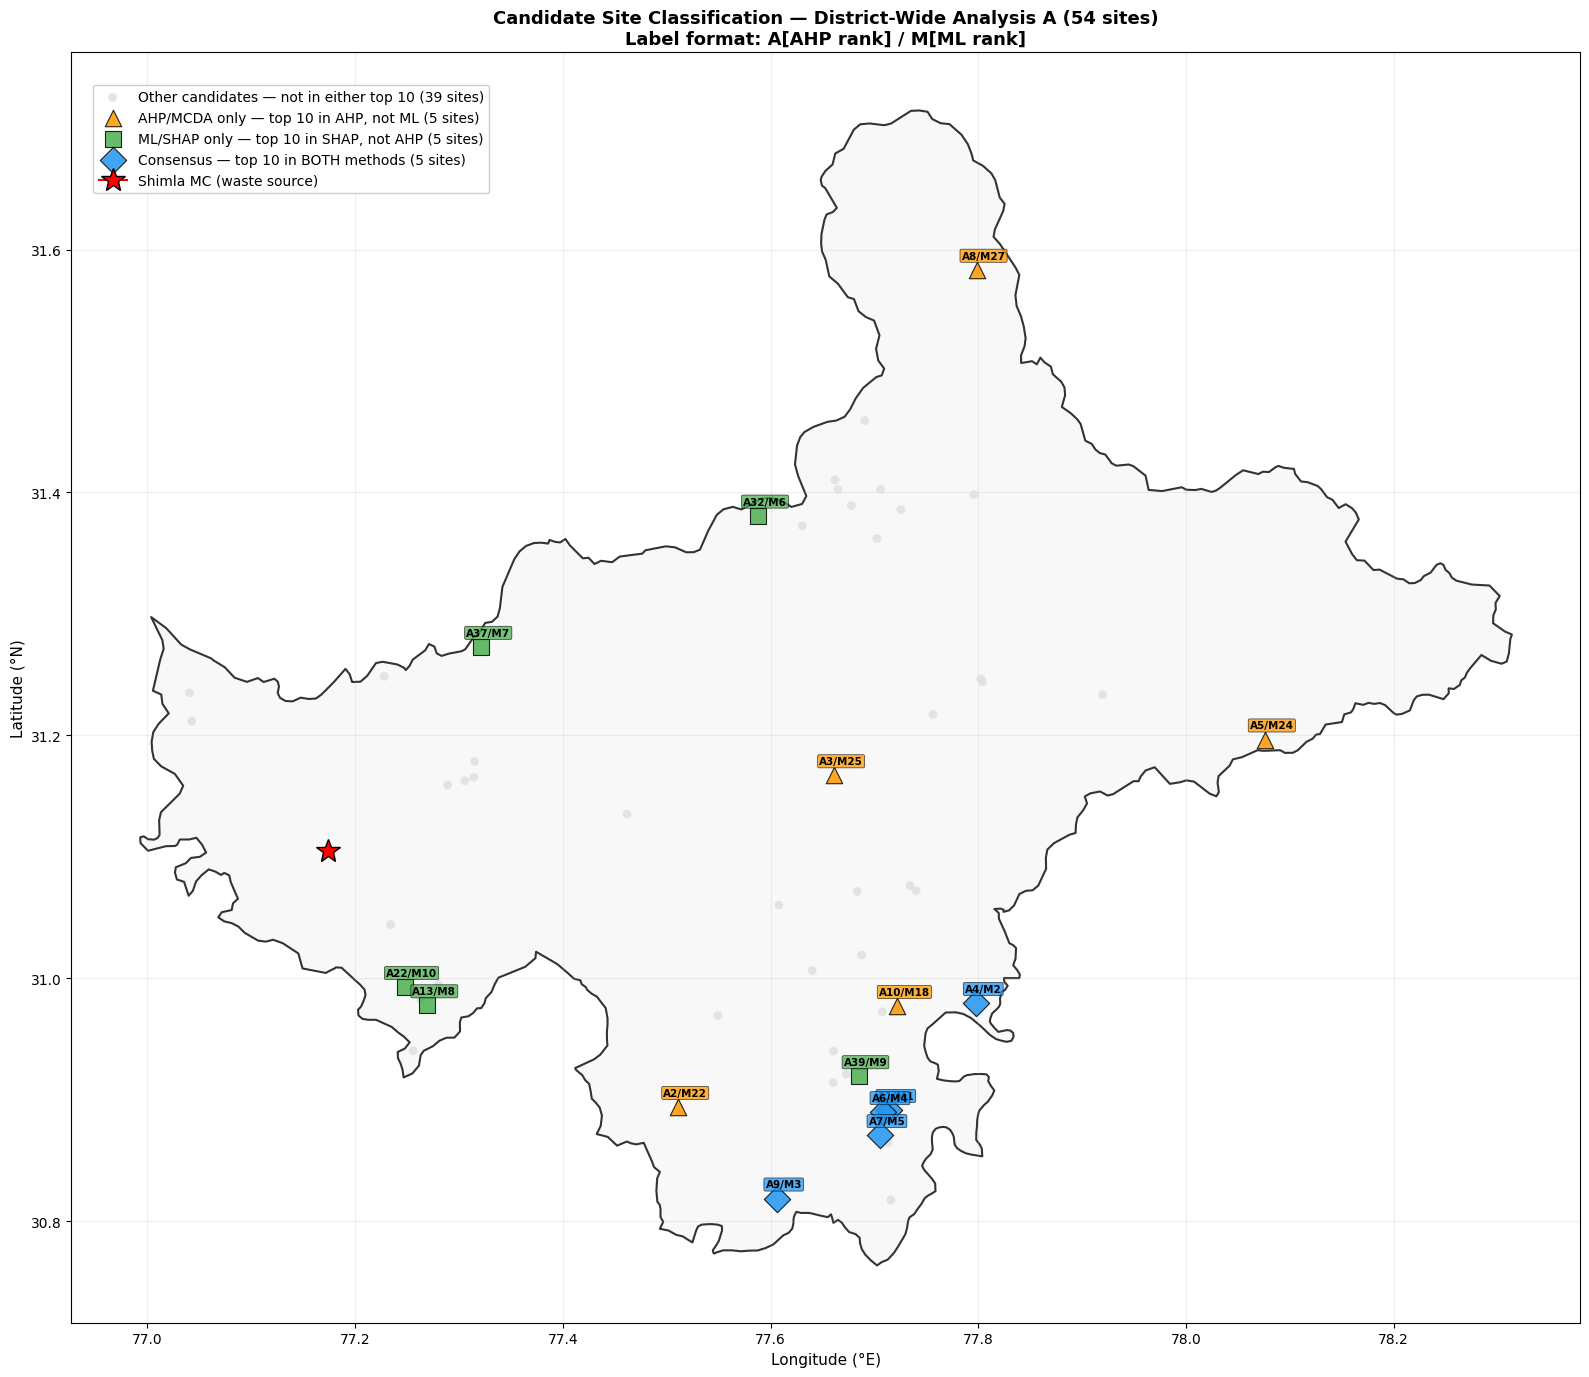

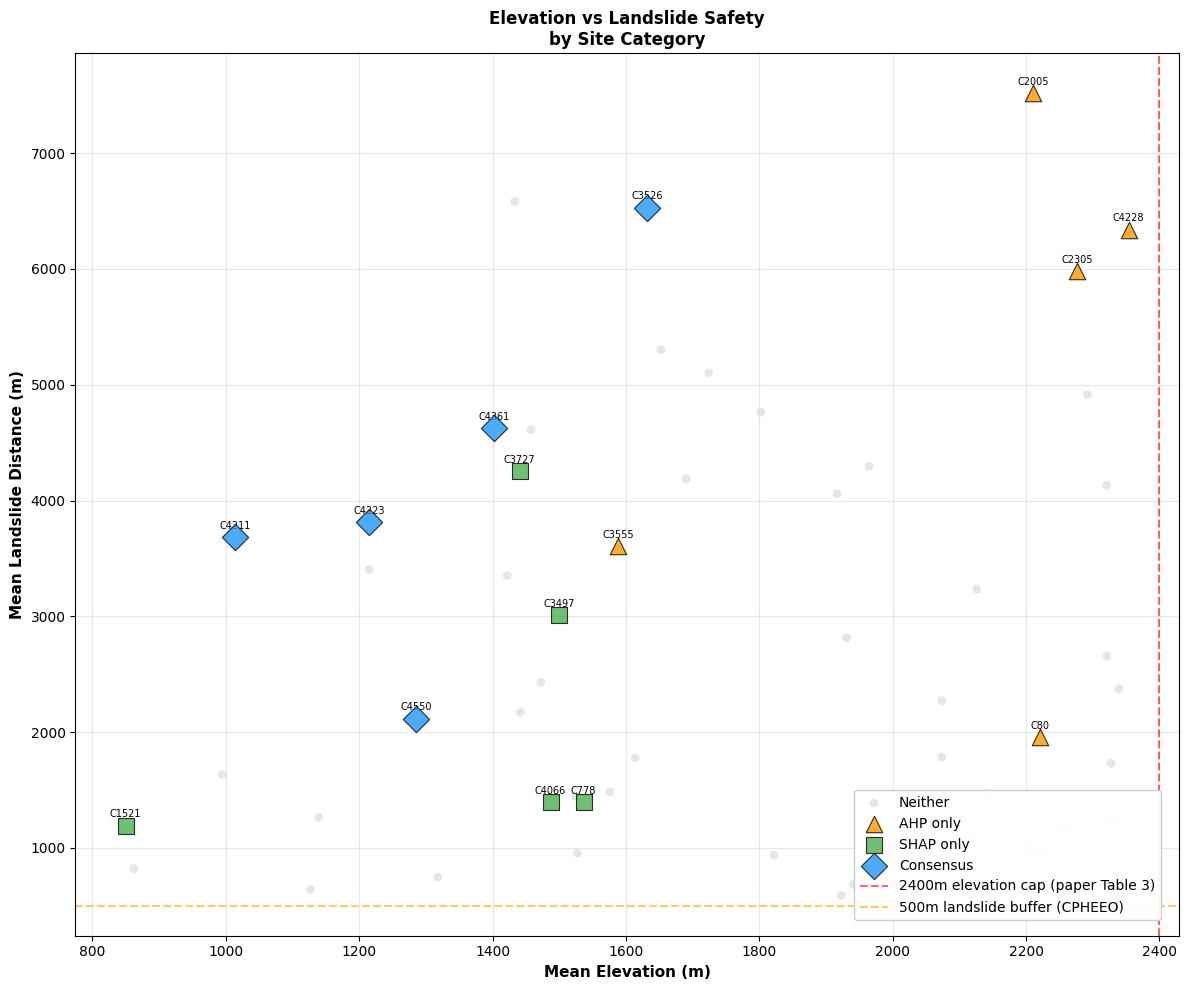

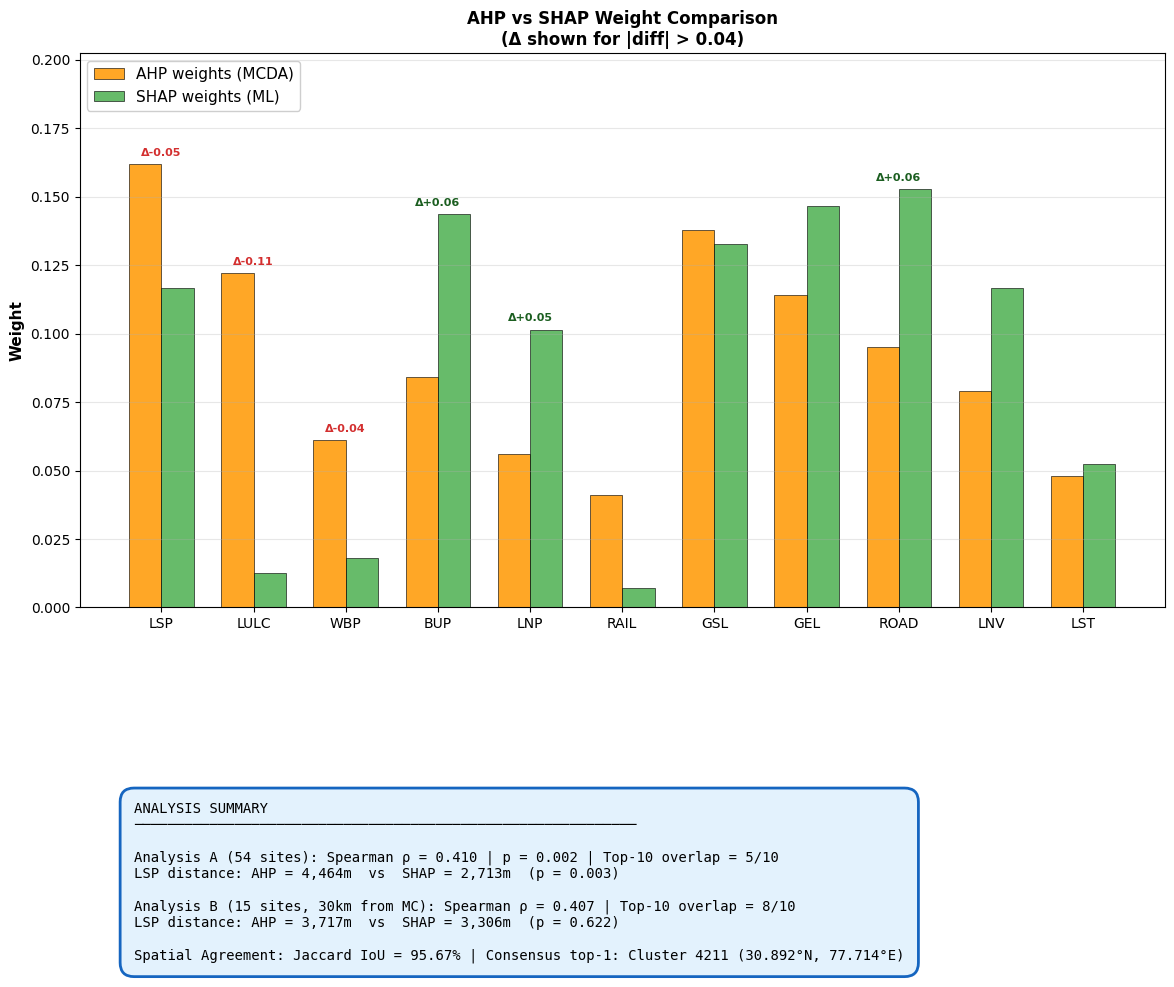


COMPLETE RESEARCH FINDINGS SUMMARY

SPATIAL AGREEMENT (B1):
  ML vs MCDA high suitability zones: Jaccard IoU = 95.67%
  Unique-to-ML patches > 10ha: 0  |  Unique-to-MCDA: 1
  → ML independently reproduces MCDA's spatial pattern

RANKING COMPARISON — ANALYSIS A (54 sites, district-wide):
  Spearman ρ = 0.410 (p = 0.002)  → Weak rank agreement
  Top-10 overlap = 5/10
  AHP mean LSP distance (top-20): 4,464m
  SHAP mean LSP distance (top-20): 2,713m
  Mann-Whitney p = 0.003  → Statistically significant

RANKING COMPARISON — ANALYSIS B (15 sites, 30km from MC):
  Spearman ρ = 0.407 (p = 0.132)  → Weak, not significant (small n)
  Top-10 overlap = 8/10
  LSP difference not significant (p = 0.622, n=10 too small)

CONSENSUS SITE (top-1 in BOTH methods):
  Cluster 4211  |  30.892N, 77.714E
  Elevation: 1015m  |  Slope: 14.7°
  Road distance: 69m  |  Landslide distance: 3683m
  → Strongest recommendation — supported by expert judgment AND data

KEY FINDING ON LANDSLIDE PROXIMITY:
  AHP assign

In [17]:
# ============================================================
# FINAL SUMMARY: CONSENSUS vs METHOD-SPECIFIC SITES
# ============================================================
# Shows which sites are recommended by BOTH methods (consensus),
# only by AHP/MCDA, or only by SHAP/ML — for both Analysis A
# (54 sites, district-wide) and Analysis B (15 sites, 30km radius)
# ============================================================
print("=" * 60)
print("FINAL SUMMARY: CONSENSUS vs METHOD-SPECIFIC SITES")
print("=" * 60)

from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# ---- LOAD BOTH RANKING FILES ----
ahp_path  = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
shap_path = os.path.join(result_folder, "B_ML_VIKOR_ranked_sites.csv")

sites_ahp  = pd.read_csv(ahp_path)
sites_shap = pd.read_csv(shap_path)

# Merge on cluster_id
merged = sites_ahp[["cluster_id", "vikor_rank", "Qi",
                      "mean_landslide_dist", "mean_elevation",
                      "mean_road_dist", "mean_slope", "area_ha",
                      "centroid_lat", "centroid_lon"]].copy()
merged = merged.rename(columns={"vikor_rank": "ahp_rank", "Qi": "Qi_ahp"})
merged = merged.merge(
    sites_shap[["cluster_id", "ml_rank", "Qi_shap"]],
    on="cluster_id", how="inner"
)

# ---- DEFINE TOP-N THRESHOLDS ----
TOP_N = 10

top_ahp  = set(merged.nsmallest(TOP_N, "ahp_rank")["cluster_id"])
top_shap = set(merged.nsmallest(TOP_N, "ml_rank")["cluster_id"])

consensus    = top_ahp & top_shap
ahp_only     = top_ahp - top_shap
shap_only    = top_shap - top_ahp
neither_top  = set(merged["cluster_id"]) - top_ahp - top_shap

def get_category(cid):
    if cid in consensus:   return "Consensus"
    if cid in ahp_only:    return "AHP only"
    if cid in shap_only:   return "SHAP only"
    return "Neither"

merged["category"] = merged["cluster_id"].apply(get_category)

# ---- SUMMARY TABLE ----
print(f"\nTop-{TOP_N} site classification (Analysis A, 54 sites):")
print(f"  Consensus (both AHP & SHAP top-{TOP_N}):  {len(consensus)} sites")
print(f"  AHP only (MCDA top-{TOP_N}, not ML):       {len(ahp_only)} sites")
print(f"  SHAP only (ML top-{TOP_N}, not MCDA):      {len(shap_only)} sites")

print(f"\nConsensus sites (ranked by AHP):")
print(f"  {'Cluster':<10} {'AHP Rank':>9} {'ML Rank':>9} {'Elev':>7} {'LSP':>7} {'Road':>7} {'Lat':>9} {'Lon':>9}")
print("  " + "-" * 70)
for _, row in merged[merged["category"] == "Consensus"].sort_values("ahp_rank").iterrows():
    print(f"  {int(row['cluster_id']):<10} {int(row['ahp_rank']):>9} {int(row['ml_rank']):>9} "
          f"{row['mean_elevation']:>7.0f} {row['mean_landslide_dist']:>7.0f} "
          f"{row['mean_road_dist']:>7.0f} {row['centroid_lat']:>9.4f} {row['centroid_lon']:>9.4f}")

print(f"\nAHP-only sites (favored by expert weights, not ML):")
print(f"  {'Cluster':<10} {'AHP Rank':>9} {'ML Rank':>9} {'Elev':>7} {'LSP':>7} {'Road':>7}")
print("  " + "-" * 60)
for _, row in merged[merged["category"] == "AHP only"].sort_values("ahp_rank").iterrows():
    print(f"  {int(row['cluster_id']):<10} {int(row['ahp_rank']):>9} {int(row['ml_rank']):>9} "
          f"{row['mean_elevation']:>7.0f} {row['mean_landslide_dist']:>7.0f} "
          f"{row['mean_road_dist']:>7.0f}")

print(f"\nSHAP-only sites (favored by ML weights, not expert):")
print(f"  {'Cluster':<10} {'AHP Rank':>9} {'ML Rank':>9} {'Elev':>7} {'LSP':>7} {'Road':>7}")
print("  " + "-" * 60)
for _, row in merged[merged["category"] == "SHAP only"].sort_values("ml_rank").iterrows():
    print(f"  {int(row['cluster_id']):<10} {int(row['ahp_rank']):>9} {int(row['ml_rank']):>9} "
          f"{row['mean_elevation']:>7.0f} {row['mean_landslide_dist']:>7.0f} "
          f"{row['mean_road_dist']:>7.0f}")

# ---- MEAN CHARACTERISTICS PER CATEGORY ----
print(f"\nMean characteristics by category (top-{TOP_N} sites):")
print(f"  {'Category':<15} {'N':>3} {'Mean Elev':>11} {'Mean LSP':>10} {'Mean Road':>11} {'Mean Slope':>11}")
print("  " + "-" * 65)
for cat in ["Consensus", "AHP only", "SHAP only"]:
    subset = merged[merged["category"] == cat]
    if len(subset) > 0:
        print(f"  {cat:<15} {len(subset):>3} "
              f"{subset['mean_elevation'].mean():>11.0f} "
              f"{subset['mean_landslide_dist'].mean():>10.0f} "
              f"{subset['mean_road_dist'].mean():>11.0f} "
              f"{subset['mean_slope'].mean():>11.1f}")

# ============================================================
# VISUALIZATION
# ============================================================
print(f"\nGenerating final summary visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig1, ax1 = plt.subplots(figsize=(16, 14))

# Color and marker scheme
cat_colors  = {"Consensus": "#2196F3", "AHP only": "#FF9800", "SHAP only": "#4CAF50", "Neither": "#E0E0E0"}
cat_markers = {"Consensus": "D", "AHP only": "^", "SHAP only": "s", "Neither": "o"}
cat_sizes   = {"Consensus": 180, "AHP only": 140, "SHAP only": 140, "Neither": 40}
cat_labels  = {
    "Consensus": f"Consensus — top {TOP_N} in BOTH methods ({len(consensus)} sites)",
    "AHP only":  f"AHP/MCDA only — top {TOP_N} in AHP, not ML ({len(ahp_only)} sites)",
    "SHAP only": f"ML/SHAP only — top {TOP_N} in SHAP, not AHP ({len(shap_only)} sites)",
    "Neither":   f"Other candidates — not in either top {TOP_N} ({len(neither_top)} sites)",
}

# ============================================================
# PLOT 1: Main map — all 54 sites categorized
# ============================================================
shimla_latlon.plot(ax=ax1, facecolor="#F8F8F8", edgecolor="#333333", linewidth=1.5)

# Plot by category
for cat in ["Neither", "AHP only", "SHAP only", "Consensus"]:
    subset = merged[merged["category"] == cat]
    if len(subset) == 0:
        continue
    ax1.scatter(
        subset["centroid_lon"], subset["centroid_lat"],
        c=cat_colors[cat],
        marker=cat_markers[cat],
        s=cat_sizes[cat],
        alpha=0.85,
        edgecolors="black" if cat != "Neither" else "none",
        linewidth=0.8,
        label=cat_labels[cat],
        zorder=5 if cat != "Neither" else 3
    )

# Annotate consensus and top-method sites
for _, row in merged[merged["category"] != "Neither"].iterrows():
    ahp_r = int(row["ahp_rank"])
    ml_r  = int(row["ml_rank"])
    label = f"A{ahp_r}/M{ml_r}"
    ax1.annotate(
        label,
        (row["centroid_lon"], row["centroid_lat"]),
        fontsize=7.5, fontweight="bold",
        xytext=(5, 8), textcoords="offset points",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.15",
                  facecolor=cat_colors[row["category"]],
                  alpha=0.75, edgecolor="black", linewidth=0.5),
        zorder=6
    )

# Shimla MC marker
ax1.plot(77.1734, 31.1048, marker="*", color="red", markersize=18,
         markeredgecolor="black", markeredgewidth=1,
         label="Shimla MC (waste source)", zorder=10)

ax1.set_title(f"Candidate Site Classification — District-Wide Analysis A (54 sites)\n"
              f"Label format: A[AHP rank] / M[ML rank]",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=11)
ax1.set_ylabel("Latitude (°N)", fontsize=11)
ax1.legend(loc="upper left", fontsize=10, framealpha=0.95,
           bbox_to_anchor=(0.01, 0.98), borderaxespad=0.5)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "D1_Site_Map_Categorized.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: Elevation vs Landslide Distance scatter
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 10))

for cat in ["Neither", "AHP only", "SHAP only", "Consensus"]:
    subset = merged[merged["category"] == cat]
    if len(subset) == 0:
        continue
    ax2.scatter(
        subset["mean_elevation"],
        subset["mean_landslide_dist"],
        c=cat_colors[cat],
        marker=cat_markers[cat],
        s=cat_sizes[cat],
        alpha=0.8,
        edgecolors="black" if cat != "Neither" else "none",
        linewidth=0.8,
        label=cat,
        zorder=5 if cat != "Neither" else 3
    )

# Annotate top sites
for _, row in merged[merged["category"] != "Neither"].iterrows():
    ax2.annotate(
        f"C{int(row['cluster_id'])}",
        (row["mean_elevation"], row["mean_landslide_dist"]),
        fontsize=7, ha="center", xytext=(0, 6),
        textcoords="offset points"
    )

ax2.axvline(x=2400, color="red", linestyle="--", alpha=0.6, linewidth=1.5,
            label="2400m elevation cap (paper Table 3)")
ax2.axhline(y=500, color="orange", linestyle="--", alpha=0.6, linewidth=1.5,
            label="500m landslide buffer (CPHEEO)")

ax2.set_xlabel("Mean Elevation (m)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Mean Landslide Distance (m)", fontsize=11, fontweight="bold")
ax2.set_title("Elevation vs Landslide Safety\nby Site Category", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10, loc="lower right", framealpha=0.95,
           bbox_to_anchor=(0.99, 0.01), borderaxespad=0.5)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "D2_Elevation_vs_Landslide.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 3: Weight comparison bar chart
# ============================================================
from matplotlib import gridspec
fig3 = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5, figure=fig3)
ax3 = fig3.add_subplot(gs[0])

criteria_short = ["LSP", "LULC", "WBP", "BUP", "LNP", "RAIL",
                   "GSL", "GEL", "ROAD", "LNV", "LST"]
ahp_vals  = [ahp_weights_raw[c]  for c in criteria_cols]
shap_vals = [shap_weights_raw[c] for c in criteria_cols]

x_pos = np.arange(len(criteria_short))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, ahp_vals,  width, label="AHP weights (MCDA)",
                color="#FF9800", alpha=0.85, edgecolor="black", linewidth=0.5)
bars2 = ax3.bar(x_pos + width/2, shap_vals, width, label="SHAP weights (ML)",
                color="#4CAF50", alpha=0.85, edgecolor="black", linewidth=0.5)

# Highlight biggest changes
for i, (a, s, code) in enumerate(zip(ahp_vals, shap_vals, criteria_short)):
    diff = abs(s - a)
    if diff > 0.04:
        ax3.annotate(f"Δ{s-a:+.2f}",
                     xy=(i, max(a, s) + 0.003),
                     ha="center", fontsize=8, fontweight="bold",
                     color="#D32F2F" if s < a else "#1B5E20")

ax3.set_xticks(x_pos)
ax3.set_xticklabels(criteria_short, fontsize=10)
ax3.set_ylabel("Weight", fontsize=11, fontweight="bold")
ax3.set_title("AHP vs SHAP Weight Comparison\n(Δ shown for |diff| > 0.04)",
              fontsize=12, fontweight="bold")
ax3.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax3.grid(axis="y", alpha=0.3)
ax3.set_ylim(0, max(max(ahp_vals), max(shap_vals)) * 1.25)

# ============================================================
# OVERALL TITLE AND SUMMARY STATS BOX
# ============================================================
# Analysis box as a subplot below the bar chart
ax_summary = fig3.add_subplot(gs[1])
ax_summary.axis("off")

line = "─" * 60

summary_text = (
    f"ANALYSIS SUMMARY\n"
    f"{line}\n\n"
    f"Analysis A (54 sites): Spearman ρ = 0.410 | p = 0.002 | Top-10 overlap = 5/10\n"
    f"LSP distance: AHP = 4,464m  vs  SHAP = 2,713m  (p = 0.003)\n\n"
    f"Analysis B (15 sites, 30km from MC): Spearman ρ = 0.407 | Top-10 overlap = 8/10\n"
    f"LSP distance: AHP = 3,717m  vs  SHAP = 3,306m  (p = 0.622)\n\n"
    f"Spatial Agreement: Jaccard IoU = 95.67% | Consensus top-1: Cluster 4211 (30.892°N, 77.714°E)"
)

ax_summary.text(0.05, 0.95, summary_text, transform=ax_summary.transAxes,
                fontsize=10, verticalalignment="top", family="monospace",
                bbox=dict(boxstyle="round,pad=1", facecolor="#E3F2FD",
                          edgecolor="#1565C0", linewidth=2))

plt.savefig(os.path.join(result_folder, "D3_Weight_Comparison_with_Summary.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================
print(f"\n{'=' * 60}")
print("COMPLETE RESEARCH FINDINGS SUMMARY")
print("=" * 60)
print(f"""
SPATIAL AGREEMENT (B1):
  ML vs MCDA high suitability zones: Jaccard IoU = 95.67%
  Unique-to-ML patches > 10ha: 0  |  Unique-to-MCDA: 1
  → ML independently reproduces MCDA's spatial pattern

RANKING COMPARISON — ANALYSIS A (54 sites, district-wide):
  Spearman ρ = 0.410 (p = 0.002)  → Weak rank agreement
  Top-10 overlap = 5/10
  AHP mean LSP distance (top-20): 4,464m
  SHAP mean LSP distance (top-20): 2,713m
  Mann-Whitney p = 0.003  → Statistically significant

RANKING COMPARISON — ANALYSIS B (15 sites, 30km from MC):
  Spearman ρ = 0.407 (p = 0.132)  → Weak, not significant (small n)
  Top-10 overlap = 8/10
  LSP difference not significant (p = 0.622, n=10 too small)

CONSENSUS SITE (top-1 in BOTH methods):
  Cluster 4211  |  30.892N, 77.714E
  Elevation: 1015m  |  Slope: 14.7°
  Road distance: 69m  |  Landslide distance: 3683m
  → Strongest recommendation — supported by expert judgment AND data

KEY FINDING ON LANDSLIDE PROXIMITY:
  AHP assigns LSP highest weight (0.162)
  SHAP assigns LSP rank 5 (0.117)
  AHP top sites have 65% greater landslide distance than SHAP top sites
  → AHP over-weights landslide proximity relative to terrain reality
  → In Shimla, areas far from landslides are also remote/inaccessible
  → This terrain correlation is invisible to AHP but captured by ML
""")